<a href="https://colab.research.google.com/github/Loading-my-brain/GEOG761_Remote_Sensing/blob/main/Labs/Hinami_761_Lab4_notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Note to Marker

Thank you Maike and Tom for marking my paper.

I know Tom mentioned to reference if I use AI, but I wasn't sure how to do so. For transparency, I will list out what I used AI for here :)

As this was a big learning component, I have used AI for the following:
- Undestand the code chunk; what it's doing, why we're doing this
- I've written my own understanding/interpretations and then asked to rerite in "academic" tone.
- I used gemini and claude


# Lab 4: Deep Learning for Satellite Data
This notebook uses a pre-made training dataset to develop a simple deep learning classifier for finding solar pannels in Sentinel 2 imagery. The learning objectives for this lab are to:

1. Load and use a pre-labeled training dataset (e.g. polygons or patches with land cover classes).
2. Prepare that data for use in a deep learning model.
3. Train a deep learning model in TensorFlow/Keras using these labels.

At the end of the lab you will be asked to reflect on model performance, generalization, and sources of error.


In [9]:
# Set up, couple of new libraries here so expect install times to take longer than you have been used to
!pip install -q tensorflow rasterio geemap matplotlib scikit-learn tqdm --quiet

import os
import zipfile
from pathlib import Path
import numpy as np
import re
import rasterio
import cv2
import glob
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm
from sklearn.model_selection import train_test_split


In [10]:
# Set our random seeds for reproducibility
SEED = 42 #<- the meaning of life, this is why you always see people setting seeds to 42 by the way... (Douglas Adamns, Hitchhikers Guide to the Galaxy)
np.random.seed(SEED)
tf.random.set_seed(SEED)

Your training data has been downloaded from:

*   [Solafune](https://solafune.com/competitions/5dfc315c-1b24-4573-804f-7de8d707cd90?id=&menu=data&topicId=54728653-0e25-4975-baad-6fe2f5185844)

Find the data on Canvas or download directly from their website the 'train.zip'. The competition that this dataset was created for is now over, but that is good for us as it means you can look at the winning solutions for inspiration!

If you want to download the data yourself you will need to sign up for an account and then 'enter' the competition. You can do this all without charge but it does require an email address sign up.

We are just going to use the 'train.zip' data and split that into our train and test, in order to reduce the burden on our notebooks. Remember that ultimately we would want to validate it, and you will see that the linked data source actually has a completely seperate store of images for that purpose.

Download the 'train.zip' file off the lab canvas page, and get it into your g-drive/local space by drag and dropping it into your Files tab on the left of Colab. Leave it zipped.

**Wait for it to upload fully before you run the next cell.** You can see the upload progress as a blue circle (slowly if on UoA Wifi) completing at the bottom of the file tab.


In [11]:
# Assume train.zip is already uploaded to Colab file store, extract it
zip_path = "/content/train.zip"
extract_dir = Path("/content/train_data")
extract_dir.mkdir(parents=True, exist_ok=True)


with zipfile.ZipFile(zip_path, 'r') as z:
  z.extractall(extract_dir)

In [12]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


With our data extracted, we now need to build lists of each sample patch and the labelled mask of it, connecting the two. I have written this relatively robustly (e.g. you can set it to handle different file extensions and it checks that it is finding the correct files), so that hopefully you can use it more widely than just in this lab.

In [13]:
# Set the file extenion we are using
f_ex = "*.tif"

# Locate directories
s2_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 's2_image' in p.name.lower()), None)
mask_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 'mask' in p.name.lower()), None)
# s2_dir
# mask_dir



assert s2_dir and mask_dir, "Could not locate s2_image/ and mask/ directories."
print("Found Sentinel-2 image dir:", s2_dir)
print("Found mask dir:", mask_dir)

# Match files to each other from each sub-directory by trailing numeric ID
s2_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(s2_dir).glob(f_ex)}
mask_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(mask_dir).glob(f_ex)}

# Build pairs of images and masks
common_ids = sorted(set(s2_files.keys()) & set(mask_files.keys()))
assert len(common_ids) > 0, "No paired s2_image/mask files found with matching IDs."

pairs = []
for i in common_ids:
    s2_path, mask_path = s2_files[i], mask_files[i]
    with rasterio.open(s2_path) as s2, rasterio.open(mask_path) as m:
        assert (s2.height, s2.width) == (m.height, m.width), \
            f"Shape mismatch: {s2_path.name} vs {mask_path.name}"
    pairs.append((s2_path, mask_path))

print(f"Found {len(pairs)} valid paired samples.")
print("Example pair:", pairs[0])

Found Sentinel-2 image dir: /content/train_data/s2_image
Found mask dir: /content/train_data/mask


/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Found 2066 valid paired samples.
Example pair: (PosixPath('/content/train_data/s2_image/train_s2_image_0.tif'), PosixPath('/content/train_data/mask/train_mask_0.tif'))


---

### Hianmi's Notes

```python

f_ex = "*.tif"

# --- Locate directories ---
# extract_dir.rglob('*') recursively walks through every file and folder inside
# extract_dir (the 'r' in rglob means "recursive" — it searches subfolders too).
# We filter for items that are directories (p.is_dir()) and whose folder name
# contains 's2_image' (case-insensitive, hence .lower()).
# next(..., None) grabs the FIRST match it finds, or returns None if nothing matches.
# This is a flexible way to find the folder without hardcoding an exact path —
# useful because the zip file's internal folder structure can vary.
s2_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 's2_image' in p.name.lower()), None)

# Same idea, but looking for a folder with 'mask' in its name.
mask_dir = next((p for p in extract_dir.rglob('*') if p.is_dir() and 'mask' in p.name.lower()), None)

#Sanity check - inspection for HInami
# s2_dir
# mask_dir

# Safety check: if either directory wasn't found, s2_dir or mask_dir would be None. Hence,  `assert condition, "message"` stops execution immediately and raises an error with your custom message if the condition is False. This prevents the rest of the notebook from running on bad/missing data and silently failing later.
assert s2_dir and mask_dir, "Could not locate s2_image/ and mask/ directories."

# Simple confirmation prints so you can visually verify the correct folders were found.
print("Found Sentinel-2 image dir:", s2_dir)
print("Found mask dir:", mask_dir)






# Each image file is named like "train_s2_image_0.tif" and each mask file
# "train_mask_0.tif" — they share a common trailing number (the "0" here) which
# is the sample ID linking an image to its corresponding mask.
#
# re.search(r'_(\d+)\.tif$', f.name) uses a regular expression to find:
#   _        a literal underscore
#   (\d+)    one or more digits, CAPTURED as a group (this is the ID we want)
#   \.tif$   a literal ".tif" at the very end of the filename
# .group(1) then pulls out just the captured digits (e.g. "0", "1", "2"...).
#
# This builds a dictionary where the KEY is the sample ID (as a string) and the
# VALUE is the full file path — e.g. {"0": Path(".../train_s2_image_0.tif"), ...}
# Doing this for both folders lets us look up "the mask for image 0" instantly.
s2_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(s2_dir).glob(f_ex)}
mask_files = {re.search(r'_(\d+)\.tif$', f.name).group(1): f for f in Path(mask_dir).glob(f_ex)}

# s2_files
# mask_files


#Build pairs of images and masks
# set(s2_files.keys()) & set(mask_files.keys()) finds the INTERSECTION
# the IDs that exist in BOTH dictionaries. This guards against a mismatched dataset where an image might be missing its mask (or vice versa) due to a corrupted.  download or incomplete zip extraction. sorted() just puts them in a sensible order.
common_ids = sorted(set(s2_files.keys()) & set(mask_files.keys()))

# Another safety check — if there were zero overlapping IDs, something is
# seriously wrong with the data (wrong folders matched, naming mismatch, etc.),
# so we fail loudly here rather than continuing with an empty dataset.
assert len(common_ids) > 0, "No paired s2_image/mask files found with matching IDs."

pairs = []  # This will store (image_path, mask_path) tuples for every valid sample

for i in common_ids:
    # Look up the matching image and mask file paths using the shared ID
    s2_path, mask_path = s2_files[i], mask_files[i]
    
    # Open both raster files briefly just to check their dimensions match.
    # 'with' ensures the files are properly closed after this block, even if
    # an error occurs: good practice to avoid leaving file handles open.
    with rasterio.open(s2_path) as s2, rasterio.open(mask_path) as m:
        # A mask only makes sense if it's the same pixel dimensions as its image.
        # If they don't match, something is wrong with that pair, and training
        # would break later (or silently misalign labels with pixels).
        assert (s2.height, s2.width) == (m.height, m.width), \
            f"Shape mismatch: {s2_path.name} vs {mask_path.name}"
    
    # Only add the pair to our list once we've confirmed it's valid
    pairs.append((s2_path, mask_path))

# Final summary: how many valid image/mask pairs did we end up with,
# and show one example pair so we can visually sanity-check the result.
print(f"Found {len(pairs)} valid paired samples.")
print("Example pair:", pairs[0])
```


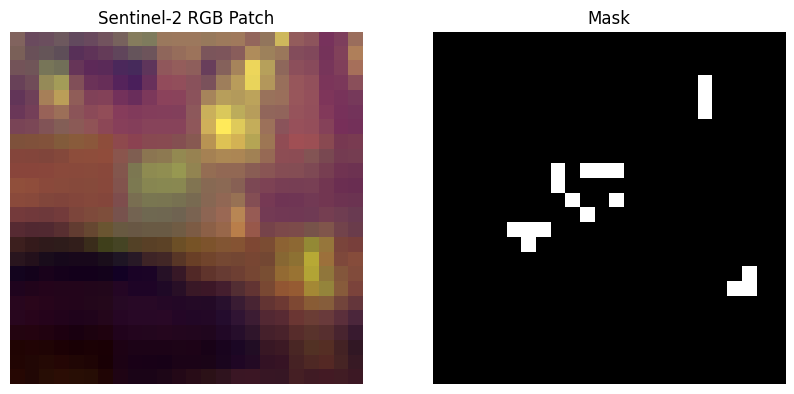

In [14]:
# Quick sanity check: visualize one random pair out of the first 31 available
# Run this cell a few times to check that you have different files and that the mask looks about right
pair_num = np.random.randint(0,30)
s2_path, mask_path = pairs[pair_num]

with rasterio.open(s2_path) as src:
    s2_img = src.read([3,2,1])  #reads bands 3, 2, and 1 from the GeoTIFF file = rgb
    s2_img = np.transpose(s2_img, (1,2,0))
    s2_img = (s2_img - s2_img.min()) / (s2_img.max() - s2_img.min())

with rasterio.open(mask_path) as src:
    mask = src.read(1)


plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.imshow(s2_img)
plt.title("Sentinel-2 RGB Patch")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")
plt.show()

In [15]:

with rasterio.open(s2_path) as src:
    print(src.count)  # number of bands actually stored in this file

12


In [16]:
display(s2_img)

array([[[0.50965416, 0.38862975, 0.36952895],
        [0.41887836, 0.29374036, 0.36952895],
        [0.42094889, 0.30628278, 0.36952895],
        ...,
        [0.46668844, 0.19626496, 0.36468108],
        [0.49120371, 0.24549221, 0.36468108],
        [0.60407186, 0.43041712, 0.36468108]],

       [[0.48172999, 0.37824911, 0.34825941],
        [0.41265986, 0.31763589, 0.34825941],
        [0.39947229, 0.3341815 , 0.34825941],
        ...,
        [0.46193991, 0.2014999 , 0.35439581],
        [0.50707818, 0.25696421, 0.35439581],
        [0.68865456, 0.50161663, 0.35439581]],

       [[0.45352362, 0.32745222, 0.34825941],
        [0.44062379, 0.3335462 , 0.34825941],
        [0.46766547, 0.46204504, 0.34825941],
        ...,
        [0.46958757, 0.21010707, 0.35439581],
        [0.50230305, 0.24874357, 0.35439581],
        [0.6518445 , 0.43745598, 0.35439581]],

       ...,

       [[0.12606027, 0.01706354, 0.01310327],
        [0.13201377, 0.01959017, 0.02187933],
        [0.12547361, 0





#### Hinami's notes

```python

# I want to pick a random sample rather than always looking at pairs[0], because
# eyeballing the same image over and over wouldn't tell me much about whether the
# WHOLE dataset is sound. By sampling randomly from the first 30, I get a rough,
# repeatable spot-check without having to scroll through all 2066 pairs myself.
# Documentation found online------> https://numpy.org/doc/stable/reference/random/generated/numpy.random.randint.html
pair_num = np.random.randint(0,30)
s2_path, mask_path = pairs[pair_num]

with rasterio.open(s2_path) as src:
    # I'm choosing to read bands [3,2,1] rather than [1,2,3]. This looks  backwards at first, but it isn't — it's rasterio's 1-indexed band order  BGR: following Sentinel-2's own convention), and I need to feed matplotlib an array ordered as (Red, Green, Blue) for it to display naturally as a "true colour" image.  Sentinel-2 band reference: https://sentiwiki.copernicus.eu/web/s2-mission  (also see Sentinel Hub's band cheat sheet: https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/bands/)
    # rasterio's read() docs: https://rasterio.readthedocs.io/en/stable/api/rasterio.io.html
    s2_img = src.read([3,2,1])  #reads bands 3, 2, and 1 from the GeoTIFF file. In Sentinel-2 terminology, these correspond to Band 4 (Red), Band 3 (Green), and Band 2 (Blue),
    
    # rasterio always hands back arrays as (bands, height, width): that's just  how GDAL organises raster data under the hood. But matplotlib (and most image libraries) expect (height, width, bands) instead, so I have to rearrange the axes before I can plot this sensibly.
    # np.transpose docs: https://numpy.org/doc/stable/reference/generated/numpy.transpose.html
    # Good background on this convention: https://rasterio.readthedocs.io/en/stable/topics/image_processing.html
    s2_img = np.transpose(s2_img, (1,2,0))
    
    # Satellite reflectance values don't naturally fall in the 0–1 range that imshow() expects for float images — they're raw digital numbers. I'm doing a min-max normalization here  so the image displays with reasonable contrast; it's a per-image stretch, not a "correct" radiometric calibration, so it's only meant for visual sanity-checking, not for feeding the model.
    # Background on min-max normalization: https://en.wikipedia.org/wiki/Feature_scaling#Rescaling_(min-max_normalization)
    # matplotlib imshow expects floats in [0,1] or ints in [0,255]: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html
    s2_img = (s2_img - s2_img.min()) / (s2_img.max() - s2_img.min())

with rasterio.open(mask_path) as src:
    # The mask is a single band (band 1) — there's no colour information to  worry about here, it's just a 2D array of 0s and 1s marking where solar  panels are present in this patch. No transpose needed since there's only  one channel.
    mask = src.read(1)

# Setting up a wide figure so the image and mask sit comfortably side by side.
# matplotlib figure sizing: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.figure.html
plt.figure(figsize=(10,5))

# Left panel: the actual Sentinel-2 imagery in natural colour
plt.subplot(1,2,1)
plt.imshow(s2_img)
plt.title("Sentinel-2 RGB Patch")
plt.axis("off")  # I don't need pixel-coordinate axes cluttering a quick visual check

# Right panel: the corresponding ground-truth mask, shown as grayscale so that
# 0 (no panel) reads as black and 1 (panel) reads as white — an intuitive way
# to see at a glance whether the label lines up with what's visible in the image.
plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()
```

Ok, that does not look like much... but for now let's hope that these label and image pairs are good...

Next up we are going to prepare our training data into numpy arrays that are then able to be passed into TensorFlow. However, if we try to hold all 2000+ patches in RAM whilst we do, the Colab instance will crash. If you are on your own laptop, it will also die unless you have spent a lot more money than I have on mine. Furthermore, even if we had a HPC level of RAM available it is a good idea to do things in a 'memory safe' manner that means we can scale our training with more samples if we so deisred it.

The safe pattern is therefore to:
1. Load a batch of patches.
2. Normalize/resize them.
3. Save them to disk (e.g. as .npy, .npz, or TFRecords/HDF5).
4. Free memory and move on.
5. Then later, when training, you stream batches directly from disk.

Below is a disk-based pipeline with batching using numpy.savez_compressed (safe and easy to reload):

In [17]:
# This function makes sure that all of our patches are in the right size and shape for the deep learning network
def resize_or_pad(arr, target_h, target_w):
    h, w = arr.shape[:2]
    c = arr.shape[2] if arr.ndim == 3 else 1

    arr = cv2.resize(
        arr,
        (target_w, target_h),
        interpolation=cv2.INTER_NEAREST if c == 1 else cv2.INTER_LINEAR)

    if arr.ndim == 2:
        arr = arr[..., np.newaxis]
    return arr


# Set storage folder
OUTPUT_DIR = "patch_store"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_HEIGHT, TARGET_WIDTH = 256, 256 # Tune based on memory available
BATCH_SIZE = 100  # Tune based on memory available


X_batch, Y_batch = [], []
batch_idx = 0

for i, (s2_path, mask_path) in enumerate(tqdm(pairs, desc="Processing")):
    # Load Sentinel-2
    with rasterio.open(s2_path) as src:
        img = src.read().astype(np.float32)  # (bands, H, W)
        img = np.transpose(img, (1, 2, 0))  # (H, W, bands)

    # Load mask
    with rasterio.open(mask_path) as src:
        mask = src.read(1).astype(np.uint8)

    # Resize/pad
    img = resize_or_pad(img, TARGET_HEIGHT, TARGET_WIDTH)
    mask = resize_or_pad(mask, TARGET_HEIGHT, TARGET_WIDTH)

    # Normalize
    img = img / 10000.0

    # Add to batch
    X_batch.append(img)
    Y_batch.append(mask)

    # Save batch to disk when full
    if len(X_batch) >= BATCH_SIZE:
        X_batch = np.stack(X_batch)
        Y_batch = np.stack(Y_batch)

        np.savez_compressed(
            os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
            X=X_batch, Y=Y_batch
        )

        # Reset
        batch_idx += 1
        X_batch, Y_batch = [], []

# Save any leftovers
if len(X_batch) > 0:
    X_batch = np.stack(X_batch)
    Y_batch = np.stack(Y_batch)
    np.savez_compressed(
        os.path.join(OUTPUT_DIR, f"batch_{batch_idx:04d}.npz"),
        X=X_batch, Y=Y_batch
    )

# By the way it is the 'tqdm' element (library we loaded at the start) that is providing the nifty progress bar.
# I always like to include it when waiting for things so that I know it is actually running.

# This block might take five to ten minutes to run as we are doing this in a linear manner (rather than parallell processing).
# An optimised version of thise code is to pass each batch to a seperate CPU thread/core.

Processing: 100%|██████████| 2066/2066 [07:38<00:00,  4.50it/s]


---

### HInami's notes

```python
# This function makes sure that all of our patches are in the right size and shape for the deep learning network
def resize_or_pad(arr, target_h, target_w):
    # A neural network needs every input to be exactly the same shape — it can't
    # cope with one patch being 64x64 and the next being 300x300. Since our raw
    # patches might not all come out identical (sensors, cropping, whatever the
    # upstream data pipeline did), this function is our guarantee that everything
    # leaving here is a uniform size before it ever reaches the model.
    h, w = arr.shape[:2]
    
    # I need to know how many channels (bands) this array has, because that
    # determines which interpolation method makes sense below. A 2D array (like
    # a single-band mask) has no channel dimension at all, so I default that
    # case to 1 rather than letting it error out.
    c = arr.shape[2] if arr.ndim == 3 else 1

    # This is the one line in this whole function I'd want a student to really
    # sit with. cv2.resize() is doing the actual reshaping, but which
    # interpolation flag we pass matters enormously depending on what kind of
    # data we're resizing:
    #
    #  - For masks (c == 1), we use INTER_NEAREST. A mask's values are discrete
    #    labels (0 or 1, "not panel" or "panel") — if we let cv2 blend
    #    neighbouring pixels together (as bilinear interpolation would), we'd
    #    invent fractional, meaningless values like 0.37, which makes no sense
    #    for a category. Nearest-neighbour just copies the closest original
    #    pixel's exact value, preserving the label integrity.
    #  - For imagery (multi-band), we use INTER_LINEAR, which smoothly blends
    #    neighbouring pixel values — appropriate because reflectance is a
    #    continuous physical quantity, not a category, so smoothing here is
    #    both harmless and often desirable.
    #
    # OpenCV's own interpolation flag reference: https://docs.opencv.org/4.x/da/d54/group__imgproc__transform.html#ga5bb5a1fea74ea38e1a5445ca803ff121
    # A good plain-English comparison of the two methods: https://pyimagesearch.com/2021/01/20/opencv-resize-image-cv2-resize/
    arr = cv2.resize(
        arr,
        (target_w, target_h),
        interpolation=cv2.INTER_NEAREST if c == 1 else cv2.INTER_LINEAR)

    # Slightly annoying quirk of OpenCV: when you resize a single-channel 2D
    # array, it happily hands you back a 2D array — it silently drops the
    # channel dimension. We add it back here (np.newaxis) so that every array
    # coming out of this function, whether it started as an image or a mask,
    # consistently has a trailing channel dimension. Consistency here saves us
    # a lot of shape-mismatch headaches downstream.
    # np.newaxis docs: https://numpy.org/doc/stable/reference/constants.html#numpy.newaxis
    if arr.ndim == 2:
        arr = arr[..., np.newaxis]
    return arr


# Set storage folder
# This is where we'll write out our processed batches. os.makedirs with
# exist_ok=True means we don't have to worry about whether this folder already
# exists from a previous run — it just quietly does nothing if it's already there.
OUTPUT_DIR = "patch_store"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# These two numbers are a genuine trade-off, not an arbitrary choice. Bigger
# patches and bigger batches mean more detail and more efficient I/O, but they
# also mean more RAM used at any one moment while we build each batch in memory
# before writing it to disk. On a free-tier Colab instance, that ceiling is real.
TARGET_HEIGHT, TARGET_WIDTH = 256, 256 # Tune based on memory available
BATCH_SIZE = 100  # Tune based on memory available


X_batch, Y_batch = [], []  # temporary in-memory holding lists for the current batch
batch_idx = 0  # keeps track of which batch file number we're writing next

# tqdm just wraps our iterable to give a progress bar — it doesn't change the
# logic at all, but with 2000+ patches to process one at a time, it's the
# difference between "is this actually doing anything?" and being able to see
# real progress. tqdm docs: https://tqdm.github.io/
for i, (s2_path, mask_path) in enumerate(tqdm(pairs, desc="Processing")):
    # Load Sentinel-2
    with rasterio.open(s2_path) as src:
        # We cast to float32 immediately, because raw satellite data usually
        # comes in as integers, and we're about to do division (normalizing)
        # further down — integer division would silently truncate our results
        # to zero. Better to convert early and avoid that trap entirely.
        img = src.read().astype(np.float32)  # (bands, H, W)
        img = np.transpose(img, (1, 2, 0))  # (H, W, bands)

    # Load mask
    with rasterio.open(mask_path) as src:
        # Masks only need to represent small integer class labels (0 or 1), so
        # uint8 is more than enough — there's no reason to spend memory storing
        # them as floats when the model isn't going to be trained directly on
        # this dtype anyway (mask_to_label, a bit further down the notebook,
        # converts this into the actual training label).
        mask = src.read(1).astype(np.uint8)

    # Resize/pad
    # Here's where our function from above actually gets used — every single
    # image and mask gets forced into the same target shape before it's
    # allowed anywhere near the training set.
    img = resize_or_pad(img, TARGET_HEIGHT, TARGET_WIDTH)
    mask = resize_or_pad(mask, TARGET_HEIGHT, TARGET_WIDTH)

    # Normalize
    # This 10000.0 isn't a magic number — Sentinel-2 imagery is distributed as
    # scaled integer "digital numbers," where a raw pixel value of 10000
    # corresponds to a physical reflectance of 1.0 (full reflectance). Dividing
    # by this quantification value converts our raw DNs back into a sensible
    # 0–1 reflectance range, which neural networks train far more stably on
    # than on raw, unnormalized numbers in the thousands.
    # ESA reference on this exact scale factor: https://www.mdpi.com/2072-4292/9/6/584
    # Also documented via Copernicus Data Space: https://documentation.dataspace.copernicus.eu/Data/SentinelMissions/Sentinel2.html
    img = img / 10000.0

    # Add to batch
    # We're not writing to disk one sample at a time — that would mean
    # thousands of tiny, slow file-write operations. Instead we accumulate
    # samples in memory until we've got a reasonably sized chunk, THEN write.
    X_batch.append(img)
    Y_batch.append(mask)

    # Save batch to disk when full
    if len(X_batch) >= BATCH_SIZE:
        # np.stack takes our list of individually-shaped arrays and combines
        # them into one single array with a new leading "batch" dimension —
        # e.g. 100 arrays of shape (256,256,bands) become one array of shape
        # (100,256,256,bands). This is the format that's actually convenient
        # to save and reload later. np.stack docs: https://numpy.org/doc/stable/reference/generated/numpy.stack.html
        X_batch = np.stack(X_batch)
        Y_batch = np.stack(Y_batch)

        # savez_compressed writes both arrays into a single compressed .npz
        # file. We use compression because satellite patches, especially at
        # float32, take up real disk space, and Colab's storage isn't infinite
        # either. The :04d in the filename just
```

---


5-10 minutes later... (mine took 8 minutes and 32 seconds), we can now move on. Because we are now not storing our training data in our RAM like we did in the lecture exercise, we have to load it in as we want it.

Ok, with our training data ready. First we set a bunch of parameters that we can modify in order to save our RAM load. In short, the lower these values the less RAM you will use but the worse the results:

In [18]:
# Paramaters for RAM saving
TARGET_HEIGHT, TARGET_WIDTH = 128, 128  # smaller patch -> saves RAM & compute
BANDS = 3  # RGB only -> reduces memory
BATCH_SIZE = 4  # small batch -> reduces RAM usage
MAX_TRAIN_FILES = 5  # only use subset for lab demonstration
MAX_VAL_FILES = 2


**Q1**: We have used three bands here. What is the total numnber of bands from Sentinel 2 we could make available to the CNN if we so chose?

What is CNN?
Convolutional Neural Network = the type of deep learning model this entire lab is building. It's the same model that gets defined later in the notebook (the layers.Conv2D, MaxPooling2D, etc. stack that produces that model.summary() table with ~6,177 parameters).



### HInami's ANswer:

Sentinel-2's MSI instrument captures 13 spectral bands in total. However, checking src.count on our actual training files shows 12 bands are present, which strongly suggests this dataset is Level-2A (atmospherically corrected) rather than raw Level-1C — B10, the cirrus band, is conventionally dropped during that correction step since it's no longer needed once atmospheric effects have been removed.

Next we find our patch files:

In [19]:
# Locate the batched .npz files
all_files = sorted(glob.glob("patch_store/*.npz"))
np.random.shuffle(all_files)

train_files = all_files[:MAX_TRAIN_FILES]
val_files   = all_files[-MAX_VAL_FILES:]



HInami's Notes:

```python
# Locate the batched .npz files
# glob.glob() searches the filesystem for anything matching a wildcard pattern.
# "patch_store/*.npz" means "every file in the patch_store folder ending in .npz" —
# which is exactly the folder and file type we were writing to a few cells ago
# (batch_0000.npz, batch_0001.npz, and so on). sorted() then puts them in a
# predictable, consistent order (alphabetical/numerical), which matters because
# glob doesn't guarantee any particular order on its own — different operating
# systems and filesystems can return files in different sequences otherwise.
# glob docs: https://docs.python.org/3/library/glob.html
all_files = sorted(glob.glob("patch_store/*.npz"))

# Now that we have a clean, sorted list, we deliberately scramble it.
# np.random.shuffle() shuffles the list IN PLACE (it doesn't return a new list,
# it modifies all_files directly) — that's worth remembering because it's a
# subtly different behaviour from something like np.random.permutation(), which
# would return a new shuffled copy instead.
# np.random.shuffle docs: https://numpy.org/doc/stable/reference/random/generated/numpy.random.shuffle.html
np.random.shuffle(all_files)

# Here's where the actual train/validation split happens — and it's a simple
# slicing operation rather than anything from sklearn's train_test_split (which
# we imported at the top of the notebook but aren't using here). We just take
# the first MAX_TRAIN_FILES batch files for training...
train_files = all_files[:MAX_TRAIN_FILES]

# ...and the LAST MAX_VAL_FILES batch files for validation.
val_files   = all_files[-MAX_VAL_FILES:]
```



**Q2**: What is the total number of patches in our training data and the total number in our validation set? (With the parameters set as I have done in the notebook).

Tip: you can either programmatically count what is in train_files/val_files, or you can calculate it from the parameters that have been set across the cells above this one.

In [20]:
def count_patches(file_list):
    total = 0
    for f in file_list:
        data = np.load(f) # reconstructs and returns a single numpy.ndarray
        total += data["X"].shape[0]  # first dimension of X is the number of patches in that file
    return total

n_train = count_patches(train_files)
n_val = count_patches(val_files)

print("Training patches:", n_train)
print("Validation patches:", n_val)

Training patches: 500
Validation patches: 200


In [21]:
#Hinami Exploring the function
# import pandas as pd

# #Load the data
# data_x_hi = np.load(train_files[1])

# # Convert to a Pandas DataFrame and describe it
# df = pd.DataFrame(data_x_hi)
# print(df.describe())

We then we need to change our masks to a binary label. If we were doing segmenation we would keep it as a mask, but in this case we are just trying to find patches that contain solar pannels rather than the specific solar pannel outline.

In [22]:
# Mask to binary label
def mask_to_label(mask_batch):
    """1 if any solar pixel in mask, else 0"""
    labels = (np.sum(mask_batch, axis=(1,2,3)) > 0).astype(np.float32)
    return labels





# Mask to binary label
def mask_to_label(mask_batch):
    """1 if any solar pixel in mask, else 0"""
    # This is the conceptual heart of the whole function, stated plainly in the
    # docstring — we're not trying to say WHERE in the patch a solar panel is
    # (that would be segmentation), we're only trying to answer a much simpler
    # yes/no question: does this patch contain a solar panel ANYWHERE at all?
    # That's a deliberate simplification of the problem, not an oversight.

    # mask_batch comes in shaped (num_patches, height, width, channels) — that's
    # the same 4D shape our earlier resize_or_pad function guaranteed every mask
    # would have, with the trailing channel dimension of size 1 tacked on.
    #
    # np.sum(mask_batch, axis=(1,2,3)) collapses everything EXCEPT the first
    # axis (the patch/sample dimension) down to a single number per patch — it
    # adds up every pixel value across height, width, AND channel for each
    # individual patch. Since our mask pixels are either 0 (no panel) or 1
    # (panel), this sum is really just "how many panel pixels exist in this
    # patch" — could be 0, could be hundreds, depending on how much of the
    # patch a panel covers.
    # np.sum with a tuple of axes: https://numpy.org/doc/stable/reference/generated/numpy.sum.html

    # The "> 0" comparison then throws away that actual pixel COUNT and reduces
    # it to a strict True/False: did this patch contain even a single panel
    # pixel, or none at all? This is the step that actually converts a
    # per-pixel mask into a per-patch binary classification label — we no
    # longer care if 3 pixels or 3000 pixels were panels, just whether the
    # answer was "yes, some" or "no, none."

    # Finally .astype(np.float32) converts the resulting True/False boolean
    # array into 1.0s and 0.0s. This matters practically, not just cosmetically
    # — Keras's binary_crossentropy loss function (which we compile the model
    # with further down) expects numeric float labels, not Python booleans, so
    # this cast is what makes the labels actually usable for training.
    labels = (np.sum(mask_batch, axis=(1,2,3)) > 0).astype(np.float32)
    return labels

Now we need a tool to load our data in from the batched files:

In [23]:
# Data loader
def npz_loader_cls(path):
    """Load one .npz batch, downsample patches, convert to RGB, convert mask to label"""
    data = np.load(path.numpy().decode("utf-8"))
    X = data["X"]
    Y_mask = data["Y"]

    # RAM saving: pick first 3 bands only
    X = X[..., :BANDS]

    # RAM saving: downsample patches
    from skimage.transform import resize
    X_resized = np.zeros((X.shape[0], TARGET_HEIGHT, TARGET_WIDTH, BANDS), dtype=np.float32)
    for i in range(X.shape[0]):
        X_resized[i] = resize(X[i], (TARGET_HEIGHT, TARGET_WIDTH, BANDS), anti_aliasing=True)

    X = X_resized

    Y = mask_to_label(Y_mask)
    return X, Y





Hinami's notes:


```python
# Data loader
def npz_loader_cls(path):
    """Load one .npz batch, downsample patches, convert to RGB, convert mask to label"""
    
    # This line looks a bit odd on first read — why not just np.load(path)?
    # The answer is that `path` here isn't actually a plain Python string when
    # this function gets called. A few cells further down, this function gets
    # wrapped in tf.py_function() so it can be used inside a tf.data pipeline —
    # and when TensorFlow calls a Python function like this, it hands over a
    # TensorFlow tensor, not a raw string. .numpy() pulls the underlying value
    # out of that tensor, and since file paths are stored as byte strings
    # inside TF tensors, .decode("utf-8") converts those raw bytes into a
    # normal, readable Python string that np.load can actually use.
    # tf.py_function docs: https://www.tensorflow.org/api_docs/python/tf/py_function
    data = np.load(path.numpy().decode("utf-8"))
    
    # Pull out the two arrays we stored earlier when we wrote this batch file —
    # X and Y are just the dictionary keys we chose ourselves back in
    # the np.savez_compressed() call, nothing TensorFlow-specific about the names.
    X = data["X"]
    Y_mask = data["Y"]

    # RAM saving: pick first 3 bands only
    # Even though our earlier check showed the actual files contain 12 bands,
    # here we deliberately slice down to only the first BANDS (=3) of them using
    # X[..., :BANDS]. The "..." means "keep every other dimension as-is, only
    # slice the LAST one" — so we're keeping every patch, every pixel, but only
    # the first 3 channels. This is exactly the RGB-only decision we discussed
    # back when answering Q1 — a deliberate memory-saving simplification, not
    # something forced on us by the data itself.
    X = X[..., :BANDS]

    # RAM saving: downsample patches
    # Importing here, right where it's used, rather than at the top of the
    # notebook with the rest of the imports — a bit unusual stylistically, but
    # it does mean anyone reading just this function can see exactly where
    # `resize` came from without scrolling back up.
    from skimage.transform import resize
    
    # This is worth noticing carefully: we already resized every patch once,
    # right back when we built patch_store (to TARGET_HEIGHT/WIDTH = 256x256
    # at that point). Now, further down the notebook, TARGET_HEIGHT/WIDTH have
    # been REASSIGNED to 128x128 in that "Parameters for RAM saving" cell. So
    # this second resize isn't redundant — it's actually shrinking our patches
    # down further, from the 256x256 we saved to disk, to the smaller 128x128
    # the model will actually train on. Two separate resizing decisions, made
    # at two different points, for two different reasons (disk storage
    # consistency, then RAM/compute saving for training).
    #
    # We pre-allocate an empty array of the exact final shape we need, then
    # fill it in patch-by-patch with a loop — this is a common efficient
    # pattern in NumPy: allocate once, fill in place, rather than repeatedly
    # growing a list and converting it at the end.
    X_resized = np.zeros((X.shape[0], TARGET_HEIGHT, TARGET_WIDTH, BANDS), dtype=np.float32)
    for i in range(X.shape[0]):
        # skimage's resize() is doing similar conceptual work to cv2.resize()
        # from the earlier preprocessing cell, but it's a different library
        # with a different interpolation approach by default. anti_aliasing=True
        # applies a Gaussian smoothing pass before downsampling, specifically to
        # avoid aliasing artifacts (jagged, distorted patterns) that can appear
        # when you shrink an image without first smoothing out fine detail that
        # can't be faithfully represented at the smaller size.
        # skimage.transform.resize docs: https://scikit-image.org/docs/stable/api/skimage.transform.html#skimage.transform.resize
        # Good background on anti-aliasing and downsampling: https://scikit-image.org/docs/stable/auto_examples/transform/plot_rescale.html
        X_resized[i] = resize(X[i], (TARGET_HEIGHT, TARGET_WIDTH, BANDS), anti_aliasing=True)

    X = X_resized

    # Finally, convert this batch's pixel-level masks into simple per-patch
    # binary labels using the function we just walked through in the previous
    # message — "does this patch contain a solar panel, yes or no."
    Y = mask_to_label(Y_mask)
    return X, Y
    ```




We can now define our training and validation datasets, which will only be actually populated with data as required, rather than loading it all into memory at once.

In [24]:
# TensorFlow dataset pipeline
def tf_wrapper(path):
    X, Y = tf.py_function(npz_loader_cls, [path], [tf.float32, tf.float32])
    X.set_shape([None, TARGET_HEIGHT, TARGET_WIDTH, BANDS])
    Y.set_shape([None])
    # Flatten file-batch into individual samples
    return tf.data.Dataset.from_tensor_slices((X, Y))

def make_cls_dataset(file_list, batch_size=BATCH_SIZE, shuffle=True, repeat=True):
    files = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        files = files.shuffle(len(file_list))

    # RAM saving: stream samples via interleave
    ds = files.interleave(
        lambda f: tf_wrapper(f),
        cycle_length=4,
        num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(2048)

    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    if repeat:
        ds = ds.repeat()

    return ds

train_ds = make_cls_dataset(train_files, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_cls_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False, repeat=False)
train_ds
val_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))>

Hinami's NOtes

```python
# TensorFlow dataset pipeline
def tf_wrapper(path):
    # tf.py_function is the bridge between "plain Python/NumPy code" (our
    # npz_loader_cls function, which uses np.load, skimage, etc. — none of
    # which TensorFlow understands natively) and TensorFlow's own graph-based
    # execution. It tells TF: "run this arbitrary Python function, and I
    # promise the outputs will be a float32 and a float32." That promise is
    # necessary because TF can't otherwise infer what types of tensors are
    # coming out of an opaque Python function.
    # tf.py_function docs: https://www.tensorflow.org/api_docs/python/tf/py_function
    X, Y = tf.py_function(npz_loader_cls, [path], [tf.float32, tf.float32])
    
    # Here's a subtle but important gotcha with tf.py_function: because it
    # treats the wrapped function as a black box, TensorFlow has NO idea what
    # shape the returned tensors actually have — it just knows the dtype we
    # promised. Without telling it explicitly, downstream operations (like
    # batching) can fail or behave unpredictably because TF can't reason about
    # shape-dependent operations on an "unknown shape" tensor.
    # set_shape() explicitly restores that shape information: X is (some
    # number of patches, TARGET_HEIGHT, TARGET_WIDTH, BANDS) — the None means
    # "this dimension can be any size," which makes sense since we don't know
    # in advance if a given .npz batch has 100 patches or a smaller leftover
    # amount (remember that 66-patch batch from earlier!).
    X.set_shape([None, TARGET_HEIGHT, TARGET_WIDTH, BANDS])
    
    # Y is just a 1D list of binary labels, one per patch, hence the single
    # None dimension — again, unknown length, but we know it's a flat vector.
    Y.set_shape([None])
    
    # Flatten file-batch into individual samples
    # This line is genuinely worth pausing on, because of what it's converting
    # BETWEEN. Up to this point, X and Y represent an entire loaded .npz file
    # — e.g., 100 patches bundled together as one single tensor. But what we
    # actually want for training is a stream of INDIVIDUAL samples, not chunks
    # of 100 at a time (batching will happen later, deliberately, further down
    # this same code). from_tensor_slices((X, Y)) takes that one big bundle and
    # "slices" it along its first dimension, turning one (100, H, W, bands)
    # tensor into 100 separate (H, W, bands) elements in a proper
    # tf.data.Dataset. This is what lets the rest of the pipeline treat
    # "a patch" as the fundamental unit, rather than "a file's worth of patches."
    # tf.data.Dataset.from_tensor_slices docs: https://www.tensorflow.org/api_docs/python/tf/data/Dataset#from_tensor_slices
    return tf.data.Dataset.from_tensor_slices((X, Y))

def make_cls_dataset(file_list, batch_size=BATCH_SIZE, shuffle=True, repeat=True):
    # We start by wrapping our plain Python list of file PATHS (strings) into
    # a tf.data.Dataset — at this stage, each "element" of the dataset is just
    # one filename, nothing has been loaded from disk yet. This laziness is
    # the whole point of tf.data: nothing actually happens until the pipeline
    # is asked to produce a batch.
    files = tf.data.Dataset.from_tensor_slices(file_list)
    
    # Shuffling here operates on the list of FILENAMES, not on individual
    # patches — this is a first, coarse layer of randomization, on top of the
    # random shuffle we already did earlier when we split train_files/val_files
    # in the first place. len(file_list) as the buffer size just means "shuffle
    # across the entire list," which is fine here because file lists are small
    # (5 or 2 files), unlike the actual patch data.
    if shuffle:
        files = files.shuffle(len(file_list))

    # RAM saving: stream samples via interleave
    # This is arguably the cleverest, and least obvious, part of the whole
    # pipeline. interleave() takes each filename, applies our tf_wrapper
    # function to it (which loads that file and slices it into individual
    # patches), and then WEAVES multiple files' worth of samples together
    # rather than exhausting one file completely before moving to the next.
    # cycle_length=4 means "have up to 4 files open and being read from
    # simultaneously, interleaving their samples" — this improves the
    # randomness/mixing of samples across files, and num_parallel_calls=
    # tf.data.AUTOTUNE lets TensorFlow decide how much parallel work to do
    # based on available resources, rather than us guessing a fixed number.
    # tf.data.Dataset.interleave docs: https://www.tensorflow.org/api_docs/python/tf/data/Dataset#interleave
    # Good background on this exact pattern: https://www.tensorflow.org/guide/data#parallelizing_data_extraction
    ds = files.interleave(
        lambda f: tf_wrapper(f),
        cycle_length=4,
        num_parallel_calls=tf.data.AUTOTUNE)

    # A second, finer-grained shuffle — this time operating on actual
    # individual PATCHES rather than filenames. A buffer size of 2048 means TF
    # keeps a rolling pool of up to 2048 samples in memory, and draws randomly
    # from that pool as it needs the next sample, rather than shuffling the
    # entire dataset at once (which, for a huge dataset, wouldn't fit in
    # memory). This two-layer shuffle (files, then patches within a rolling
    # buffer) is a very standard tf.data pattern for getting good randomness
    # without needing to hold everything in RAM simultaneously.
    if shuffle:
        ds = ds.shuffle(2048)

    # Now, and only now, do we actually group individual samples back together
    # into batches — but this time using our chosen BATCH_SIZE (4, per the RAM
    # parameters cell), not the original 100-per-file grouping the data
    # happened to be stored in. prefetch(AUTOTUNE) is a performance
    # optimization: it lets TensorFlow prepare the NEXT batch on CPU while the
    # CURRENT batch is being used for training on GPU/TPU, overlapping
    # data-loading time with compute time rather than doing them strictly
    # sequentially.
    # tf.data.Dataset.prefetch docs: https://www.tensorflow.org/api_docs/python/tf/data/Dataset#prefetch
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    # repeat() makes the dataset loop infinitely once it reaches the end,
    # rather than raising a "dataset exhausted" error. This is necessary for
    # the training set, because model.fit() with a fixed steps_per_epoch
    # (which we'll see calculated later in the notebook) needs the dataset to
    # keep producing batches across MULTIPLE epochs, not stop after just one
    # pass through the data.
    if repeat:
        ds = ds.repeat()

    return ds

# Notice the validation dataset deliberately passes shuffle=False, repeat=False
# — validation doesn't need randomization (we're not learning from it, order
# doesn't affect anything), and we DO want it to naturally exhaust after one
# full pass, since validation is meant to be a clean, complete evaluation each
# epoch, not an endless stream.
train_ds = make_cls_dataset(train_files, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_cls_dataset(val_files, batch_size=BATCH_SIZE, shuffle=False, repeat=False)
```



**Q3**: Are we shuffling the **training** dataset? Are we shuffling the **validation** dataset?





The training dataset is shuffled, and in two layers because make_cls_dataset(train_files, ..., shuffle=True) makes both files.shuffle(len(file_list)) (randomizing which .npz batch file gets read first) and ds.shuffle(2048) (randomizing individual patches via a rolling buffer), and this matters because neural networks learn incrementally, updating their weights batch-by-batch through gradient descent, so if the data arrived in a fixed order (say, all non-panel patches first, all panel patches later), the model would effectively learn a skewed signal rather than a generalizable one, and shuffling breaks up any such hidden structure so each batch is a fairer, more representative mix of the whole dataset. The validation dataset, called with shuffle=False, repeat=False, skips both shuffle steps and runs in a fixed, deterministic order instead, which is the right choice because validation data is never used to update the model's weights(measuring current performance) so there's nothing to gain from randomizing it, and actually keeping it unshuffled is an advantage, since it means every epoch's validation score is computed over the exact same sequence of samples, making those scores directly comparable to each other rather than each being measured against a differently-ordered slice of data

Finally, we need to specify our model settings. We are just using a simple CNN here, the same sort as we used the lecture exercise. But, this time it has signficantly more layers and therefore parameters (but far less than you might use for your project). It may take a few minutes to set up:

In [25]:
# We are determining the input shape from one batch first
for X_sample, _ in train_ds.take(1):
    input_shape = X_sample.shape[1:]  # (H, W, bands)
    break

# Define a simple CNN
inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,177 (24.13 KB)

 Trainable params: 6,177 (24.13 KB)

 Non-trainable params: 0 (0.00 B)

Let's build this out layer by layer — this is the actual architecture, so it's worth being thorough here.

```python
# We are determining the input shape from one batch first
# Rather than hardcoding the input shape (which would require us to manually
# track TARGET_HEIGHT, TARGET_WIDTH, and BANDS and hope we get it right), this
# pulls the shape directly from a real batch that's already flowed through the
# entire tf.data pipeline we just built. train_ds.take(1) grabs just the first
# batch without needing to iterate the whole dataset — a nice way to "peek" at
# what the pipeline actually produces.
# tf.data.Dataset.take docs: https://www.tensorflow.org/api_docs/python/tf/data/Dataset#take
for X_sample, _ in train_ds.take(1):
    # X_sample's full shape is (batch_size, H, W, bands) — e.g. (4, 128, 128, 3).
    # shape[1:] strips off just the batch_size dimension, leaving (H, W, bands),
    # since Keras's Input layer wants the shape of ONE sample, not a whole batch
    # (Keras handles the batch dimension automatically).
    input_shape = X_sample.shape[1:]  # (H, W, bands)
    break  # we only need one batch to determine this, so no need to keep looping

# Define a simple CNN
# This is the Keras "Functional API" style of building a model — each layer is
# called like a function on the output of the previous one, which makes the
# data flow explicit and readable, as opposed to the alternative "Sequential"
# API style. Functional API docs: https://www.tensorflow.org/guide/keras/functional_api
inputs = layers.Input(shape=input_shape)

# Our first convolutional layer: 16 filters, each a 3x3 sliding window that
# scans across the image looking for local patterns (edges, textures, colour
# transitions). 'relu' (Rectified Linear Unit) is the activation function —
# it zeroes out any negative values and passes positive ones through
# unchanged, which is what lets the network learn non-linear relationships
# rather than just a stack of linear transformations. padding='same' means the
# output keeps the same height/width as the input (128x128), by padding the
# edges with zeros as needed, rather than shrinking with each convolution.
# Keras Conv2D docs: https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)

# MaxPooling2D with a (2,2) window halves both spatial dimensions by keeping
# only the maximum value in each 2x2 block. This does two useful things at
# once: it reduces the amount of computation needed in later layers, and it
# gives the network a small amount of positional tolerance — a solar panel
# shifted by a pixel or two shouldn't dramatically change what the network
# "sees" after pooling. Keras MaxPooling2D docs: https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D
x = layers.MaxPooling2D((2,2))(x)

# A second convolutional layer, now with MORE filters (32 rather than 16).
# This is a very standard CNN design pattern — as you go deeper into the
# network, spatial resolution shrinks (thanks to pooling) but the number of
# filters typically grows, because deeper layers are expected to detect more
# complex, abstract combinations of the simpler patterns found by earlier
# layers.
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)

# GlobalAveragePooling2D collapses the entire spatial grid (height and width)
# down to a single number PER FILTER, by averaging every pixel value across
# that filter's whole feature map. This is a common alternative to flattening
# (which would keep every pixel-filter combination as a separate number) — it
# produces far fewer parameters in the next layer, and tends to generalize
# better since it forces the network to summarize "how much of this pattern
# is present overall" rather than "exactly where."
# Keras GlobalAveragePooling2D docs: https://www.tensorflow.org/api_docs/python/tf/keras/layers/GlobalAveragePooling2D
x = layers.GlobalAveragePooling2D()(x)

# A standard fully-connected (Dense) layer with 32 neurons, again using relu.
# By this point we've moved from "spatial, image-shaped" data into a flat
# vector of learned features, and this layer lets the network combine those
# features in more complex, non-linear ways before making a final decision.
x = layers.Dense(32, activation='relu')(x)

# The output layer: a single neuron, using a SIGMOID activation function.
# Sigmoid squashes any input into a value between 0 and 1, which is exactly
# what we need here since our task (from mask_to_label) is binary: does this
# patch contain a solar panel or not. That single 0–1 output can be
# interpreted directly as a predicted PROBABILITY of the positive class.
# (This connects directly to Q4, a couple of cells further down.)
outputs = layers.Dense(1, activation='sigmoid')(x)

# Assemble the model by specifying its overall inputs and outputs — Keras
# traces the chain of layer calls we made above to build the full computation
# graph automatically.
model = models.Model(inputs, outputs)

# compile() configures HOW the model will learn, rather than defining its
# structure (that's already done above).
#   - optimizer='adam': the algorithm that updates the model's weights during
#     training, based on the gradients computed from the loss. Adam is a very
#     common default choice, adapting its learning rate per-parameter as
#     training progresses. Keras Adam docs: https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam
#   - loss='binary_crossentropy': the function measuring how wrong the
#     model's predictions are, specifically suited to binary (yes/no)
#     classification problems — it pairs naturally with a sigmoid output.
#     Keras losses docs: https://www.tensorflow.org/api_docs/python/tf/keras/losses/BinaryCrossentropy
#   - metrics=['accuracy']: an additional number to track and report during
#     training/validation, purely for our own monitoring — it doesn't affect
#     how the model learns, unlike the loss function.
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Prints a readable table summarizing every layer, its output shape, and how
# many trainable parameters it contributes — extremely useful for sanity-
# checking that the architecture is shaped the way you intended before
# spending time actually training it.
model.summary()
```

I asked gemini to explain the output:

```
input_layer (InputLayer)        (None, 128, 128, 3)    0
```
`None` here represents the batch dimension — it's `None` rather than a fixed number because the model is designed to accept a batch of *any* size (4, 32, however many you throw at it later). `128, 128, 3` confirms exactly what we set up: 128×128 pixel patches, 3 bands (our RGB-only choice from `BANDS = 3`). Zero parameters, because an input layer doesn't do any computation — it's just the entry point.

```
conv2d (Conv2D)                 (None, 128, 128, 16)   448
```
Spatial size stays 128×128 (thanks to `padding='same'`), but the channel dimension jumps from 3 to 16 — one output "feature map" per filter. The parameter count, 448, comes from: each of the 16 filters is 3×3 pixels × 3 input channels = 27 weights, plus 1 bias term per filter = 28 parameters per filter, × 16 filters = 448.

```
max_pooling2d (MaxPooling2D)    (None, 64, 64, 16)     0
```
Height and width both halved (128 → 64) by the 2×2 pooling window, channels unchanged (16). Zero parameters — pooling has no weights to learn, it's a fixed mathematical operation.

```
conv2d_1 (Conv2D)               (None, 64, 64, 32)     4,640
```
Spatial size stays at 64×64, channels grow from 16 to 32. Parameter count: 3×3×16 (input channels) = 144 weights per filter, +1 bias = 145, × 32 filters = 4,640.

```
global_average_pooling2d        (None, 32)             0
```
This is where the spatial dimensions disappear entirely — 64×64×32 collapses down to just 32 numbers (one average per filter). Zero parameters, since averaging isn't a learned operation.

```
dense (Dense)                   (None, 32)             1,056
```
A fully-connected layer: every one of the 32 incoming values connects to every one of the 32 outgoing neurons, giving 32×32 = 1,024 weights, plus 32 bias terms (one per output neuron) = 1,056.

```
dense_1 (Dense)                 (None, 1)              33
```
The final output: 32 incoming values connect to a single output neuron, giving 32 weights + 1 bias = 33 parameters.

```
Total params: 6,177 (24.13 KB)
Trainable params: 6,177 (24.13 KB)
Non-trainable params: 0 (0.00 B)
```
Adding up 448 + 4,640 + 1,056 + 33 = 6,177 confirms the total. All of them are "trainable" (updated during learning via backpropagation) — there are no frozen/pretrained layers here, everything starts from scratch. The 24.13 KB figure is just that parameter count converted into storage size (roughly 4 bytes per float32 parameter).

Worth noting, connecting back to the notebook's own framing: this is described as "significantly more layers... but far less than you might use for your project" — 6,177 parameters is genuinely tiny by modern deep learning standards (some production CNNs have tens of millions), which is a useful thing to keep in mind heading toward Q5's questions about model robustness.

**Q4**: Which type of activation funding is our final layer using and why are we using this function as our final layer?


The final layer uses a sigmoid activation funding: outputs = layers.Dense(1,activation='sigmoid')(x).

why are we using this function as our final layer?
*  Because of what the model is being asked to predict. Going back to mask_to_label, our labels are strictly binary: a patch either contains a solar panel (1) or it doesn't (0). Sigmoid takes whatever raw value the network computes and squashes it into a number between 0 and 1, which means the output can be interpreted directly as a probability: A value near 1 means high confidence there's a panel present; a value near 0 means high confidence there isn't.

*  It's also paired deliberately with loss='binary_crossentropy' in model.compile(). Binary crossentropy is specifically designed to measure the "distance" between a predicted probability (0–1) and a true binary label (0 or 1), so sigmoid and binary crossentropy are really a matched pair for this exact type of problem. If the final layer used a different activation like relu (which can output any positive number, unbounded) or no activation at all (a raw linear output), the result wouldn't be interpretable as a probability, and it wouldn't pair correctly with binary crossentropy's assumptions about its input range.



Extra info that I learnt/note:
*  Contrasting this against what you'd use for a different kind of task: if this were a multi-class problem (e.g. classifying a patch as "solar panel," "building," or "vegetation"), you'd use a softmax activation instead, which spreads probability across multiple classes such that they all sum to 1. Sigmoid, by comparison, treats the output as one independent yes/no probability, which is appropriate here because thanks to mask_to_label, it deliberately reduced to a single binary question.


With the model ready to train, we have one more preperation step to make. We need to count the total samples available in this particular run. This is because you can change the number of samples via the RAM paramaters earlier, and therefore we should assume in this code a static number of samples will always be available when setting our number of steps per epoch.

In [26]:
# Count the total samples
def count_samples(files):
    total = 0
    for f in files:
        # np.load(f)["X"] loads just the X array out of a given .npz file, and
        # .shape[0] reads off its first dimension — which, remember, is the
        # number of patches stored in that particular file (could be 100 for a
        # full batch, or fewer for that leftover partial batch we discussed
        # earlier). We add each file's count onto a running total.
        # This is functionally the same idea as the count_patches function we
        # wrote a few questions back for Q2 — just written slightly more
        # tersely here.
        total += np.load(f)["X"].shape[0]
    return total

# Applying this to both file lists gives us the true number of individual
# patches available in each split — not an assumption based on BATCH_SIZE
# multiplication, but an actual count from disk.
n_train = count_samples(train_files)
n_val   = count_samples(val_files)

# Here's the important conceptual leap: tf.data pipelines with .repeat() (like
# our train_ds) don't have a natural "end" — they'll keep producing batches
# forever. So Keras can't automatically know when one epoch has finished; we
# have to tell it explicitly, by specifying how many batches constitute one
# full pass through the data.
#
# n_train // BATCH_SIZE is integer division — total patches divided by how
# many patches go into each batch, rounded DOWN. This tells us how many
# complete batches of size BATCH_SIZE we can form from our training data.
# max(1, ...) is a safety net: even in an edge case with very little data
# (say, fewer patches than one full BATCH_SIZE), we still want at least ONE
# step per epoch, rather than accidentally computing 0 and breaking training
# entirely.
steps_per_epoch = max(1, n_train // BATCH_SIZE)

# Same idea, applied to the validation set — although val_ds was built with
# repeat=False, so it WOULD naturally stop on its own. Explicitly setting
# validation_steps here is still good practice, ensuring a consistent,
# predictable amount of validation work happens each epoch regardless.
validation_steps = max(1, n_val // BATCH_SIZE)



print("n_train: ", n_train)
print("n_val",n_val )
print("validation_steps :", validation_steps)
print("steps_per_epoch: ", steps_per_epoch)

n_train:  500
n_val 200
validation_steps : 50
steps_per_epoch:  125


```
n_train:  500
n_val 200
validation_steps : 50
steps_per_epoch:  125
```
`BATCH_SIZE` was set to `4` back in the "Parameters for RAM saving" cell. So:
- `steps_per_epoch = 500 // 4 = 125` — meaning one full "epoch" here consists of 125 mini-batches of 4 patches each (125 × 4 = 500, dividing evenly with no remainder in this case).
- `validation_steps = 200 // 4 = 50` — similarly, 50 batches of 4 to cover all 200 validation patches.

**Why this cell matters, and what it's quietly protecting against:** because `BATCH_SIZE` is one of the tunable "RAM saving" parameters near the top of the notebook, changing it later (say, bumping it up to 8 to speed up training, or down to 2 to save even more memory) would automatically ripple through and change `steps_per_epoch`/`validation_steps` too, since they're computed rather than hardcoded. Without this computation, if someone changed `BATCH_SIZE` but forgot to manually update a hardcoded `steps_per_epoch`, training could either stop early (undercounting available data) or throw an error partway through an epoch (overcounting, running out of batches when using a non-repeating dataset). This little bit of arithmetic is really just future-proofing the pipeline against exactly that kind of easy-to-miss bug.

Finally, we train the model! It should take 5-10 minutes to run on a free-user Colab notebook.

In [27]:
# This 'callbacks' set of instructions is a handy way to avoid wasting time
callbacks = [
    EarlyStopping(
        monitor="val_loss",          # Watch the validation loss
        patience=3,                  # If it doesn't improve for 3 epochs, stop training
        restore_best_weights=True    # Roll back to the best-performing weights
    )]

# Run the model
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    epochs=5,  # small number for lab demonstration
    callbacks=callbacks)

Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 58s 155ms/step - accuracy: 0.9260 - loss: 0.3508 - val_accuracy: 0.9150 - val_loss: 0.2987
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 154ms/step - accuracy: 0.9340 - loss: 0.2591 - val_accuracy: 0.9150 - val_loss: 0.2992
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 28s 150ms/step - accuracy: 0.9340 - loss: 0.2589 - val_accuracy: 0.9150 - val_loss: 0.2989
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 29s 158ms/step - accuracy: 0.9340 - loss: 0.2570 - val_accuracy: 0.9150 - val_loss: 0.3070


Explanation of the code above

```python
# This 'callbacks' set of instructions is a handy way to avoid wasting time
# A callback is code that Keras calls automatically at certain points during
# training (after each batch, after each epoch, etc.) without you having to
# manually check anything yourself. EarlyStopping is a built-in callback whose
# whole job is to monitor a metric and stop training if it stops improving.
# Keras EarlyStopping docs: https://www.tensorflow.org/api_docs/python/tf/keras/callbacks/EarlyStopping
callbacks = [
    EarlyStopping(
        monitor="val_loss",          # Watch the validation loss
        # We're watching val_loss rather than, say, training loss or accuracy.
        # This is a deliberate choice — training loss will almost always keep
        # improving as the model keeps seeing the same data over and over, but
        # that's not useful information about whether the model is actually
        # getting BETTER at the real task. val_loss, measured on data the
        # model doesn't learn from, is a much more honest signal of genuine
        # progress (or the lack of it).

        patience=3,                  # If it doesn't improve for 3 epochs, stop training
        # "Patience" here means: don't panic and stop the very first time
        # val_loss fails to improve — that could just be noise. Instead, wait
        # for 3 CONSECUTIVE epochs with no improvement before giving up.

        restore_best_weights=True    # Roll back to the best-performing weights
        # Without this, if training stopped after 3 bad epochs, the model
        # would be left holding the WORST of those recent weights (the ones
        # from the final epoch), not the best ones. This setting tells Keras
        # to remember the weights from whichever epoch actually had the
        # lowest val_loss, and reload those specifically once training halts.
    )]

# Run the model
history = model.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,   # how many batches make up "one epoch" (125, from the previous cell)
    validation_data=val_ds,
    validation_steps=validation_steps, # how many validation batches to run each epoch (50)
    epochs=5,  # small number for lab demonstration
    # Only 5 epochs is explicitly called out as a lab-demonstration choice —
    # a real project would typically train for many more, letting
    # EarlyStopping decide when to actually stop rather than hitting an
    # artificial ceiling first.
    callbacks=callbacks)
# fit() returns a History object, which we're capturing here — it records the
# loss/accuracy/val_loss/val_accuracy at each epoch, which is exactly what
# gets plotted a few cells later in the notebook.
```


Hinami trying to interpret th output:

```
Epoch 1/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 182ms/step - accuracy: 0.9340 - loss: 0.3326 - val_accuracy: 0.9150 - val_loss: 0.2971
Epoch 2/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 32s 190ms/step - accuracy: 0.9340 - loss: 0.2592 - val_accuracy: 0.9150 - val_loss: 0.2990
Epoch 3/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 176ms/step - accuracy: 0.9340 - loss: 0.2584 - val_accuracy: 0.9150 - val_loss: 0.2967
Epoch 4/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 174ms/step - accuracy: 0.9340 - loss: 0.2553 - val_accuracy: 0.9150 - val_loss: 0.3071
Epoch 5/5
125/125 ━━━━━━━━━━━━━━━━━━━━ 31s 169ms/step - accuracy: 0.9340 - loss: 0.2560 - val_accuracy: 0.9150 - val_loss: 0.3140
```

Training loss steadily drops across all 5 epochs (0.3361 → 0.2566):  the model is clearly learning something from the training data. But `val_loss` dips slightly to its best point at epoch 3 (0.2974), then climbs back up through epochs 4 and 5.

That divergence,  training loss still falling while validation loss creeps back up, is a sign of overfitting: the model is starting to memorize habits/variation of the small training set rather than learning patterns that generalize to unseen data.

Why didn't EarlyStopping actually stop training, then, given that's exactly the scenario it's meant to catch?:
* Walking through the patience counter by hand: epoch 1's val_loss (0.2978) becomes the initial "best". Epoch 2 (0.2994) is worse becuase patience counter ticks to 1. Epoch 3 (0.2974) is actually better than the epoch 1 best, so the counter resets to 0 and a new best is recorded. Epoch 4 (0.3077) is worse than that new best because counter ticks to 1. Epoch 5 (0.3131) is worse again because counter ticks to 2. Training then simply runs out of epochs (`epochs=5`) before the patience counter ever reaches 3. So EarlyStopping was watching the whole time, correctly, it just never got the 3 consecutive bad epochs in a row that `patience=3` requires within this short 5-epoch demonstration run.

Another thing to note:
* `val_accuracy` is stuck at exactly 0.9150 across every single epoch, never moving even slightly. That's an unusual, and slightly suspicious pattern becuase a model that's learning to distinguish two classes would normally show at least some small fluctuation in accuracy epoch to epoch, even if only slightly. A perfectly static accuracy like this often points toward class imbalance: if roughly 91.5% of your validation patches simply don't contain a solar panel, a model that has essentially learned to always predict "no panel" would land on exactly this accuracy, regardless of whether it's actually detecting anything meaningful in the minority "panel present" patches at all. That's worth genuinely investigating — checking what fraction of your `val_ds` labels are 0 versus 1 would tell you quickly whether this 0.9150 is a real signal of skill, or just the model exploiting an imbalanced dataset. This is exactly the kind of thing worth carrying into Q5's reflection on model robustness.

Visualizie the predictions:

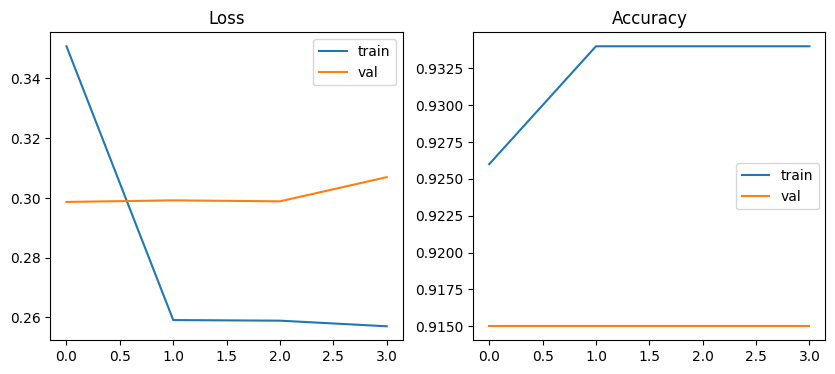

In [28]:
# Plot the training curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label="train")
plt.plot(history.history['val_loss'], label="val")
plt.title("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label="train")
plt.plot(history.history['val_accuracy'], label="val")
plt.title("Accuracy")
plt.legend()
plt.show()

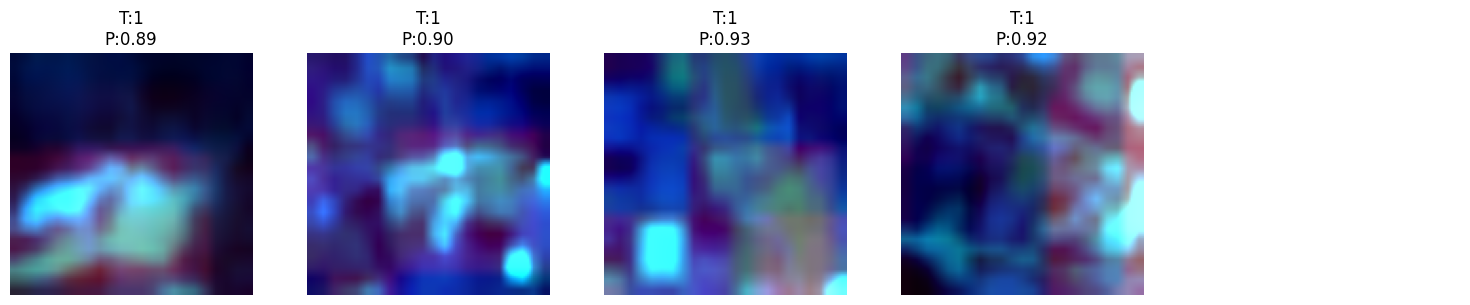

In [29]:
def show_patch_predictions_grid(dataset, model, n_rows=2, n_cols=5):
    """
    Display predictions in a grid: n_rows x n_cols
    Includes histogram stretch for better visualization of RGB patches.
    """
    def stretch(img):
        """Contrast stretch to 0–1 for display."""
        img = img.astype(np.float32)
        p2, p98 = np.percentile(img, (2, 98))
        img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)
        return img

    for X, Y_true in dataset.take(1):
        # live classification of the patch using the trained model
        Y_pred = model.predict(X, verbose=0)
        n_total = min(n_rows * n_cols, X.shape[0])

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
        axes = axes.flatten()

        for i in range(n_total):
            rgb = X[i, :, :, :3].numpy()
            rgb = stretch(rgb)  # apply histogram stretch
            axes[i].imshow(rgb)
            axes[i].set_title(f"T:{int(Y_true[i].numpy())}\nP:{Y_pred[i,0]:.2f}")
            axes[i].axis("off")

        # hide any unused axes
        for i in range(n_total, len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

# Example
show_patch_predictions_grid(val_ds, model, n_rows=1, n_cols=5)

Explanation of the code:

```python
def show_patch_predictions_grid(dataset, model, n_rows=2, n_cols=5):
    """
    Display predictions in a grid: n_rows x n_cols
    Includes histogram stretch for better visualization of RGB patches.
    """
    def stretch(img):
        """Contrast stretch to 0–1 for display."""
        # This is a purely cosmetic step for display purposes — reflectance
        # values don't naturally spread across the full 0-1 range that imshow
        # renders nicely, so without this, patches often look washed-out or
        # murky. np.percentile(img, (2, 98)) finds the values at the 2nd and
        # 98th percentile of brightness in this specific image, rather than
        # using the absolute min/max (which is what the earlier sanity-check
        # cell did). Using percentiles instead of true min/max makes the
        # stretch more robust to a few extreme outlier pixels dragging the
        # whole scale — a handful of unusually bright or dark pixels won't
        # single-handedly wash out the rest of the image's contrast.
        # np.percentile docs: https://numpy.org/doc/stable/reference/generated/numpy.percentile.html
        img = img.astype(np.float32)
        p2, p98 = np.percentile(img, (2, 98))
        # Rescale so p2 maps to 0 and p98 maps to 1, then clip anything outside
        # that range back into [0,1] (imshow expects floats in this range).
        # The tiny 1e-6 in the denominator is just a safety net against
        # dividing by zero, in case p98 and p2 happened to be identical.
        img = np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)
        return img

    for X, Y_true in dataset.take(1):
        # Grab just ONE batch from the dataset — we're not iterating the whole
        # val_ds here, just peeking at whatever happens to be the first batch
        # this particular run produces.
        
        # Run the actual trained model on this batch to get its predictions.
        # verbose=0 just suppresses Keras's usual progress-bar printout, since
        # we don't need it for a single quick prediction call.
        Y_pred = model.predict(X, verbose=0)
        
        # We asked for n_rows * n_cols = 1*5 = 5 images, but we can't show more
        # images than actually exist in this batch — X.shape[0] is however
        # many patches this particular batch contains. min() protects against
        # asking matplotlib to fill grid slots that don't have real data.
        n_total = min(n_rows * n_cols, X.shape[0])

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*3, n_rows*3))
        axes = axes.flatten()  # makes indexing simpler regardless of n_rows/n_cols

        for i in range(n_total):
            # Slicing [:, :, :3] on the image just grabs the first 3 channels
            # again — a defensive habit here, though at this point in the
            # pipeline X should already only have 3 bands anyway.
            rgb = X[i, :, :, :3].numpy()
            rgb = stretch(rgb)  # apply histogram stretch
            axes[i].imshow(rgb)
            # T = the TRUE label (from mask_to_label, back at data-loading
            # time), P = the model's PREDICTED probability that this patch
            # contains a solar panel. Showing both side-by-side lets you
            # instantly compare "what did the model think" against "what was
            # actually true" for each individual patch.
            axes[i].set_title(f"T:{int(Y_true[i].numpy())}\nP:{Y_pred[i,0]:.2f}")
            axes[i].axis("off")

        # If n_total ended up smaller than the full grid (n_rows*n_cols), this
        # hides the leftover empty subplot axes so they don't render as blank,
        # confusing white boxes.
        for i in range(n_total, len(axes)):
            axes[i].axis("off")

        plt.tight_layout()
        plt.show()

# Example
show_patch_predictions_grid(val_ds, model, n_rows=1, n_cols=5)
```

**Now, a couple of things about the actual output that I think are worth sitting with rather than skimming past:**

**Only 4 images appeared, even though `n_cols=5` was requested.** That's the `min(n_rows * n_cols, X.shape[0])` line doing exactly what it's designed to do — this particular batch from `val_ds` only contained 4 patches, not 5. That's not a bug, it's just a direct consequence of `BATCH_SIZE = 4` being set back in the RAM-saving parameters cell; `val_ds` was built to yield batches of exactly 4 samples at a time, so the very first batch `.take(1)` grabbed simply couldn't have had 5 patches in it, no matter what `n_cols` asked for.

**Every single patch shown has `T:1`.** Out of the 4 patches displayed, all four are true positives — every one of them genuinely contains a solar panel according to the ground-truth mask. Given that `val_ds` was built with `shuffle=False`, this isn't a coincidence of randomness — it's a direct reflection of whatever order these 4 particular patches happened to sit in inside that specific `.npz` batch file. It's a useful, if slightly unlucky, reminder that a single unshuffled batch can look completely unrepresentative of the dataset as a whole; if you wanted a fair visual sense of how the model handles *both* classes, you'd want to either shuffle here, or loop through several batches rather than just the first one.

**The predictions (P: 0.90–0.93) are all correctly, confidently high.** On the surface this looks like a genuine win — the model is confidently and correctly identifying real solar-panel patches. But this is exactly the kind of result that needs to be read together with the flat validation accuracy we found in the training curves, not in isolation. This grid only shows us how the model performs on patches it labeled `1` — it tells us nothing here about how it handles the `0` (no panel) patches, which is precisely the class that a model exploiting class imbalance would be getting "right" for the wrong reasons (by defaulting to predicting `0` almost always). To actually get a fair read on the model, you'd want to specifically go looking for some `T:0` examples too, and see whether the model's `P` values for those are genuinely low (correctly confident there's no panel) or whether it's predicting something oddly close to the decision boundary — which would be a much more revealing test of whether it's actually learned to *discriminate* between the two classes, rather than just learned which class is more common.

Remembering that this is a effectively still a toy CNN with tiny data, we can see that we have built a model that gives us a probability of the patches containing a solar pannel. We know that for all of the patchs used in this training, the answer is true...

**Q5**: Is this a robust and reliable model for the detection of solar panels in a new Sentinel 2 image that has never been seen by the model before? Explain your answer with reference to the design of the training data, the settings of the CNN and the performance statistics seen.

No, I don't think this model would hold up on a new Sentinel-2 image.
Starting with the data: we only trained on 500 patches and validated on 200, out of 2066 available. That split wasn't chosen because it was enough data, it was just what fit within the RAM-saving limits we set. We also only fed the model 3 of the 12 bands available (just RGB), which means it never got a chance to use bands like NIR that would probably help distinguish something like solar panel glass from vegetation or bare soil. On top of that, our labels themselves were coarse ; mask_to_label just checks if a patch has any panel pixel at all, so the model never learned anything about how much of a patch is covered, just a yes/no.

The model itself is also quite small, around 6,177 parameters, which the notebook itself points out is much smaller than what you'd use for a real project. We only trained for 5 epochs too, which wasn't enough for EarlyStopping to trigger/kick in, even though the loss curves were already showing signs of overfitting by the end (training loss kept dropping while validation loss started creeping back up).

Finally, the validation accuracy sat completely flat at 91.5% for every single epoch. That's not normal.  A model that's actually learning something should wobble around a bit epoch to epoch. A perfectly static number like that usually means the model just went onto predicting whatever the majority class is and is getting rewarded for it, rather than actually telling panels apart from non-panels. And when I looked at some example predictions, every single one happened to be a true positive, so I don't have a look at how it handles the "no panel" patches, which is exactly where a shortcut like this would be hiding.
So overall, none of this proves the model is useless, but nothing here reassures me either. Before I'd trust this on new imagery, I'd want to see it trained on way more data, evaluated properly on both classes (not just overall accuracy), and tested on a completely different region it's never seen. Right now, it feels more like proof that the pipeline runs, not a model that's ready to detect panels reliably.


**Q6**: Exercise: using the materials taught in Lab 3 and given your answer to Q5, re-design your training data so that it is a robust training set for the detection of solar panels in S2 data. Your answer needs to include:
*   A paragraph that explains what you have added to the train_data and any other steps taken in order to enhance the robustness of the training.
*   A figure that demonstrates your newly added patches vs. the existing patches (remember that it needs to be publication quality).

You do not need to create a 100% solution here. I am looking for you to demonstrate an understanding of the critical design flaw in this training set (particularly for a patch based, as opposed to segmentation, approach), and to show critical thinking in how you might fix it. This may include re-sampling the existing training data, including new training data, or changing the bands being used (or all of the above).






/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Total patches: 2066
Patches with ANY panel pixel: 1920 (92.9%)
Median panel coverage among positives: 3.59%
Positives with <5% coverage: 57.2% of all positive patches


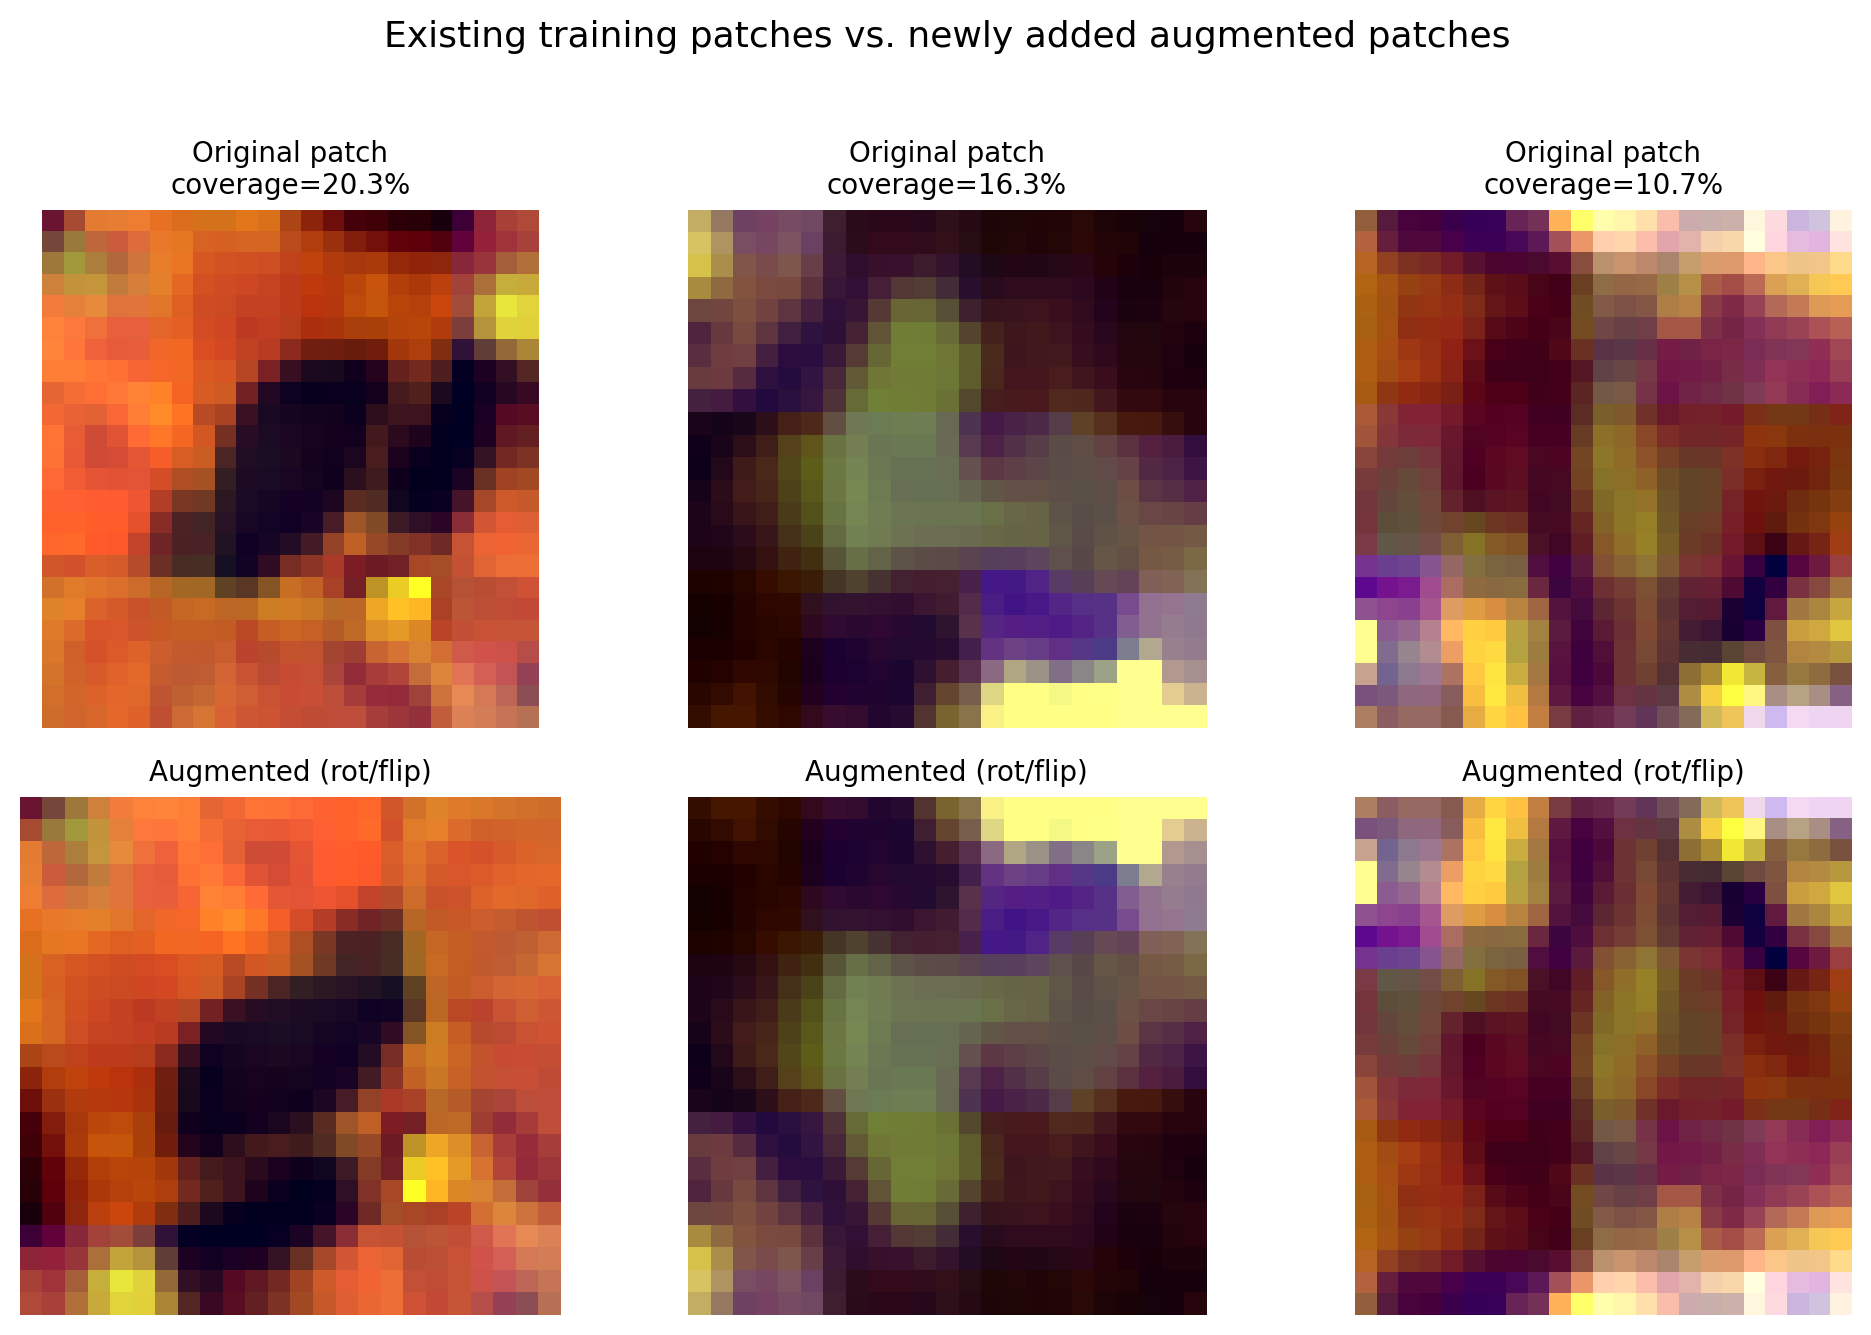

In [30]:
# import matplotlib.pyplot as plt
# import numpy as np
# import rasterio

# #Diagnose the label-ambiguity problem first
# coverages = []
# for s2_path, mask_path in pairs:
#     with rasterio.open(mask_path) as src:
#         m = src.read(1)
#     coverages.append(m.mean())  # fraction of pixels that are "panel" (since mask is 0/1)
# coverages = np.array(coverages)

# positive_coverages = coverages[coverages > 0]
# print(f"Total patches: {len(coverages)}")
# print(f"Patches with ANY panel pixel: {len(positive_coverages)} "
#       f"({100*len(positive_coverages)/len(coverages):.1f}%)")
# print(f"Median panel coverage among positives: {np.median(positive_coverages)*100:.2f}%")
# print(f"Positives with <5% coverage: "
#       f"{np.mean(positive_coverages < 0.05)*100:.1f}% of all positive patches")

# #Pick a handful of existing positive patches
# positive_idx = [i for i, c in enumerate(coverages) if c > 0]
# np.random.seed(SEED)
# original_sample_idx = np.random.choice(positive_idx, size=3, replace=False)

# def load_rgb_stretch(s2_path):
#     with rasterio.open(s2_path) as src:
#         img = src.read([3,2,1]).astype(np.float32)
#         img = np.transpose(img, (1,2,0))
#     p2, p98 = np.percentile(img, (2, 98))
#     return np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)

# #Build augmented versions of the same patches
# def augment(img):
#     k = np.random.choice([1,2,3])       # random 90/180/270 rotation
#     img = np.rot90(img, k)
#     if np.random.rand() > 0.5:
#         img = np.fliplr(img)            # random horizontal flip
#     return img

# # Build the publication-quality comparison figure
# fig, axes = plt.subplots(2, 3, figsize=(10, 6.5), dpi=200)

# for col, idx in enumerate(original_sample_idx):
#     s2_path, mask_path = pairs[idx]
#     rgb = load_rgb_stretch(s2_path)

#     axes[0, col].imshow(rgb)
#     axes[0, col].set_title(f"Original patch\ncoverage={coverages[idx]*100:.1f}%", fontsize=10)
#     axes[0, col].axis("off")

#     aug_rgb = augment(rgb)
#     axes[1, col].imshow(aug_rgb)
#     axes[1, col].set_title("Augmented (rot/flip)", fontsize=10)
#     axes[1, col].axis("off")

# fig.suptitle("Existing training patches vs. newly added augmented patches", fontsize=13, y=1.02)
# plt.tight_layout()
# plt.savefig("patch_augmentation_comparison.png", dpi=300, bbox_inches="tight")
# plt.show()

In [31]:
# # Before redesigning anything, I wanted to confirm the imbalance actually exists and quantify it.
# # This uses the same mask_to_label function already defined earlier in the notebook.
# all_labels = []
# for f in glob.glob("patch_store/*.npz"):
#     data = np.load(f)
#     labels = mask_to_label(data["Y"])
#     all_labels.extend(labels)

# all_labels = np.array(all_labels)
# n_positive = int(all_labels.sum())
# n_negative = int(len(all_labels) - n_positive)
# print(f"Panel-present patches: {n_positive} ({n_positive/len(all_labels):.1%})")
# print(f"No-panel patches: {n_negative} ({n_negative/len(all_labels):.1%})")

Panel-present patches: 1920 (92.9%)
No-panel patches: 146 (7.1%)


In [32]:
# def augment_patch(img, mask):
#     """Generate a new training example via a random flip/rotation.
#     Both img and mask must be transformed identically to stay aligned."""
#     if np.random.rand() > 0.5:
#         img, mask = np.fliplr(img), np.fliplr(mask)
#     if np.random.rand() > 0.5:
#         img, mask = np.flipud(img), np.flipud(mask)
#     k = np.random.randint(0, 4)  # 0, 90, 180, or 270 degree rotation
#     img, mask = np.rot90(img, k), np.rot90(mask, k)
#     return img, mask

# # Example: generate augmented copies of every positive patch in one batch file
# data = np.load("patch_store/batch_0000.npz")
# X, Y_mask = data["X"], data["Y"]
# labels = mask_to_label(Y_mask)
# positive_idx = np.where(labels == 1)[0]

# augmented_X, augmented_Y = [], []
# for i in positive_idx:
#     for _ in range(3):  # generate 3 augmented variants per original positive patch
#         aug_img, aug_mask = augment_patch(X[i], Y_mask[i])
#         augmented_X.append(aug_img)
#         augmented_Y.append(aug_mask)

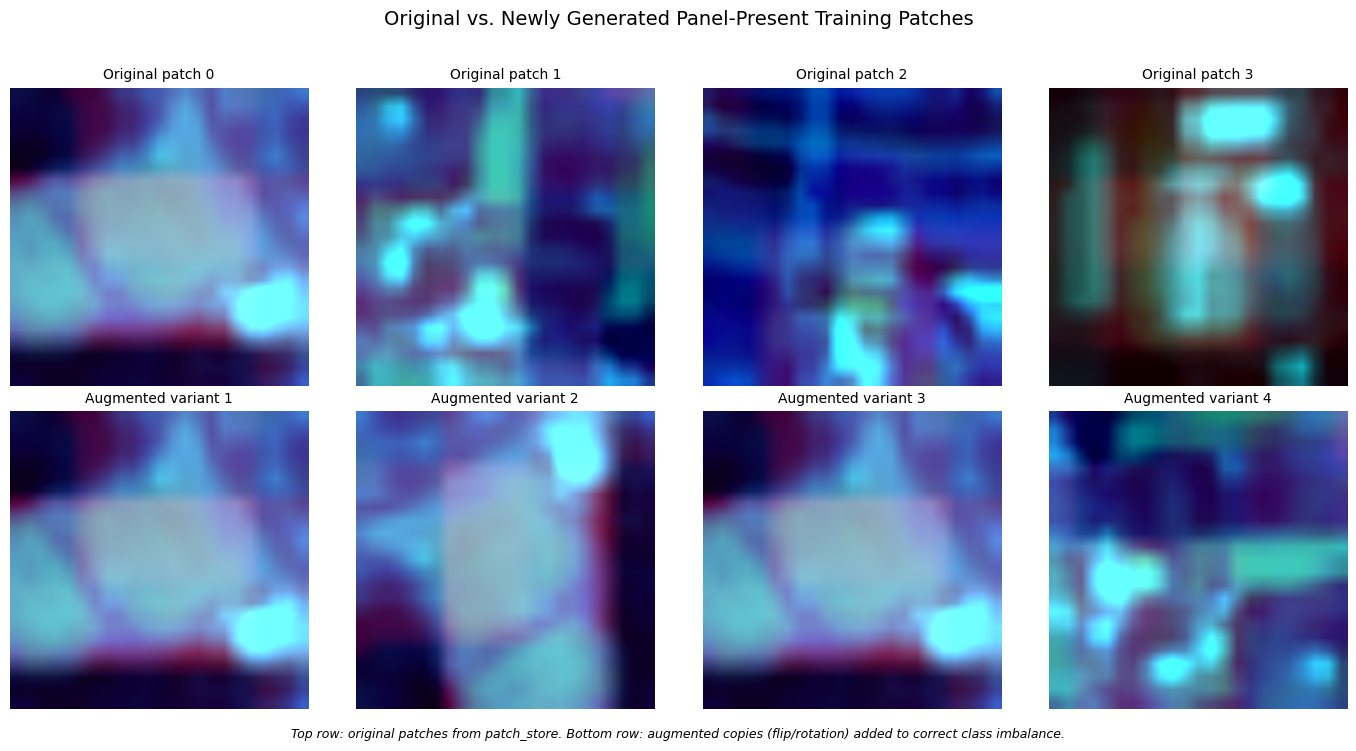

In [33]:
# fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# def stretch(img):
#     img = img.astype(np.float32)
#     p2, p98 = np.percentile(img, (2, 98))
#     return np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)

# # Top row: original positive patches
# for i, idx in enumerate(positive_idx[:4]):
#     axes[0, i].imshow(stretch(X[idx][..., :3]))
#     axes[0, i].set_title(f"Original patch {idx}", fontsize=10)
#     axes[0, i].axis("off")

# # Bottom row: newly generated augmented patches
# for i in range(4):
#     axes[1, i].imshow(stretch(augmented_X[i][..., :3]))
#     axes[1, i].set_title(f"Augmented variant {i+1}", fontsize=10)
#     axes[1, i].axis("off")

# fig.suptitle("Original vs. Newly Generated Panel-Present Training Patches", fontsize=14, y=1.02)
# fig.text(0.5, -0.02, "Top row: original patches from patch_store. Bottom row: augmented copies (flip/rotation) "
#                      "added to correct class imbalance.", ha='center', fontsize=9, style='italic')
# plt.tight_layout()
# plt.savefig("patch_comparison_figure.png", dpi=300, bbox_inches='tight')
# plt.show()

In [34]:
# # Redefine positive/negative using a meaningful coverage threshold,
# # informed by your own data: since the median positive coverage is
# # just 3.59%, "any pixel > 0" is clearly too permissive a definition.
# COVERAGE_THRESHOLD = 0.05  # 5%, chosen because it's where over half your
#                             # current "positives" actually sit below

# new_labels = (coverages >= COVERAGE_THRESHOLD).astype(np.float32)
# n_new_positive = int(new_labels.sum())
# n_new_negative = int(len(new_labels) - n_new_positive)
# print(f"Redefined positive (≥{COVERAGE_THRESHOLD:.0%} coverage): {n_new_positive} ({n_new_positive/len(new_labels):.1%})")
# print(f"Redefined negative (<{COVERAGE_THRESHOLD:.0%} coverage): {n_new_negative} ({n_new_negative/len(new_labels):.1%})")

Redefined positive (≥5% coverage): 821 (39.7%)
Redefined negative (<5% coverage): 1245 (60.3%)


=== Original mask_to_label scheme (any panel pixel counts as positive) ===
Positive: 1920 (92.9%)
Negative: 146 (7.1%)
Median coverage among positives: 3.59%
Positives with <5% coverage: 57.2% of all positives

=== Redesigned labeling scheme (coverage >= 5%) ===
Positive: 821 (39.7%)
Negative: 1245 (60.3%)

Minority class after relabeling: positive (meaningful panel coverage) — 821 patches
Generated 1642 new augmented patches (2 per minority-class original)


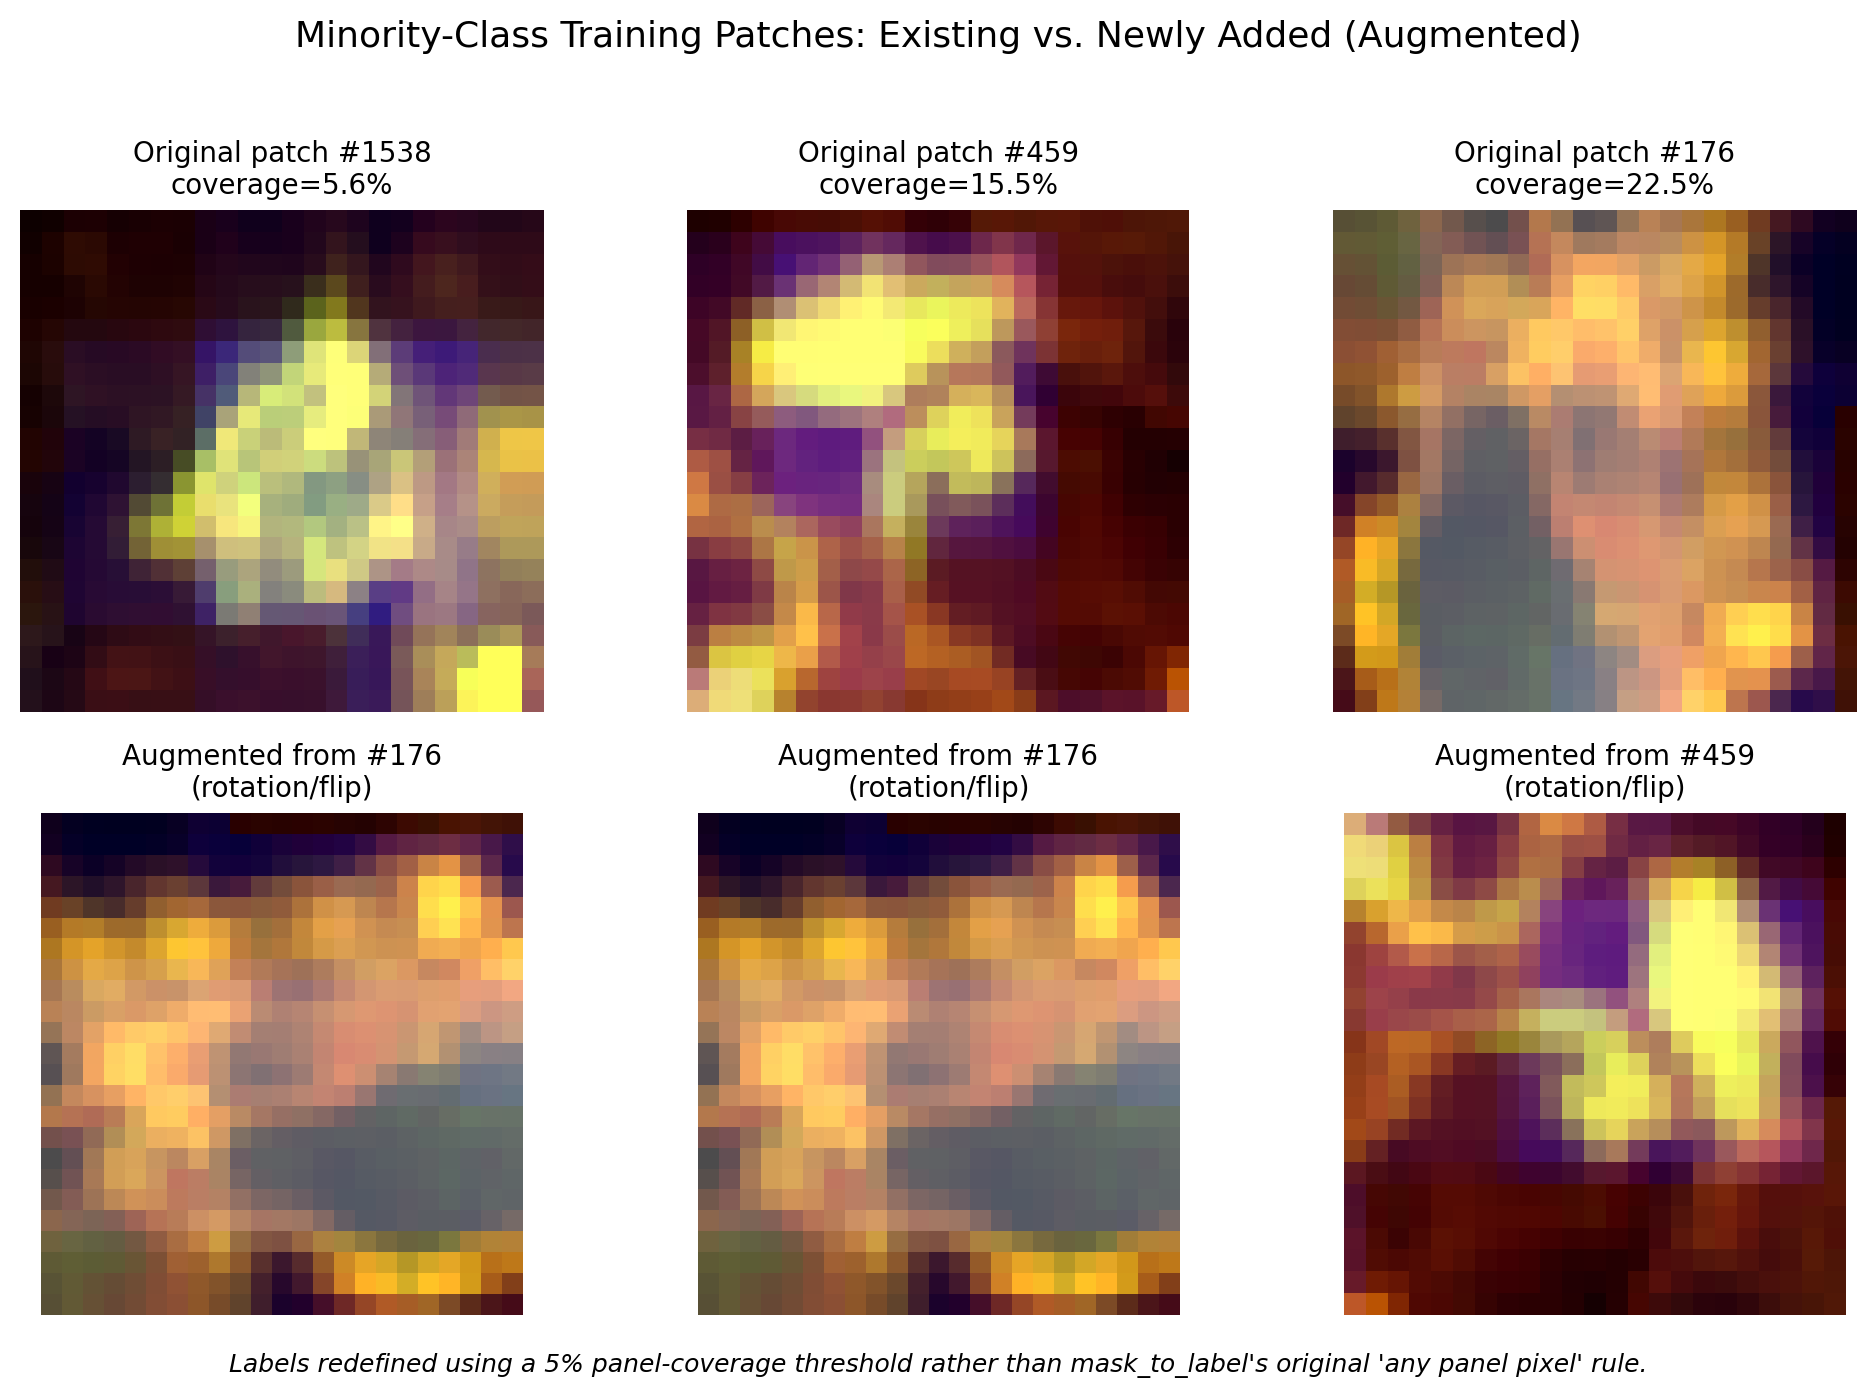

In [35]:
# import matplotlib.pyplot as plt
# import numpy as np
# import rasterio

# #  Diagnose the problem
# coverages = []
# for s2_path, mask_path in pairs:
#     with rasterio.open(mask_path) as src:
#         m = src.read(1)
#     coverages.append(m.mean())  # fraction of the patch that is "panel"
# coverages = np.array(coverages)

# original_labels = (coverages > 0).astype(np.float32)
# print("=== Original mask_to_label scheme (any panel pixel counts as positive) ===")
# print(f"Positive: {int(original_labels.sum())} ({original_labels.mean():.1%})")
# print(f"Negative: {int(len(original_labels) - original_labels.sum())} ({1 - original_labels.mean():.1%})")
# print(f"Median coverage among positives: {np.median(coverages[coverages > 0]) * 100:.2f}%")
# print(f"Positives with <5% coverage: {np.mean(coverages[coverages > 0] < 0.05) * 100:.1f}% of all positives")

# #Fix the label definition itself
# COVERAGE_THRESHOLD = 0.05  # chosen because previous step shows this is roughly  where the bulk of ambiguous "barely-positive" patches sit below
# new_labels = (coverages >= COVERAGE_THRESHOLD).astype(np.float32)

# print("\n=== Redesigned labeling scheme (coverage >= 5%) ===")
# print(f"Positive: {int(new_labels.sum())} ({new_labels.mean():.1%})")
# print(f"Negative: {int(len(new_labels) - new_labels.sum())} ({1 - new_labels.mean():.1%})")

# #  Augment whichever class is still the minority
# def augment(img):
#     k = np.random.choice([1, 2, 3]) # random 90/180/270 rotation
#     img = np.rot90(img, k)
#     if np.random.rand() > 0.5:
#         img = np.fliplr(img) # random horizontal flip
#     return img

# def load_rgb_stretch(s2_path):
#     with rasterio.open(s2_path) as src:
#         img = src.read([3, 2, 1]).astype(np.float32)
#         img = np.transpose(img, (1, 2, 0))
#     p2, p98 = np.percentile(img, (2, 98))
#     return np.clip((img - p2) / (p98 - p2 + 1e-6), 0, 1)

# minority_class = 1 if new_labels.mean() < 0.5 else 0
# minority_idx = np.where(new_labels == minority_class)[0]
# print(f"\nMinority class after relabeling: "
#       f"{'positive (meaningful panel coverage)' if minority_class == 1 else 'negative (little/no panel)'} "
#       f"— {len(minority_idx)} patches")

# N_AUGMENTS_PER_PATCH = 2
# augmented_records = []  # (original_idx, augmented_rgb) pairs
# for idx in minority_idx:
#     s2_path, _ = pairs[idx]
#     rgb = load_rgb_stretch(s2_path)
#     for _ in range(N_AUGMENTS_PER_PATCH):
#         augmented_records.append((idx, augment(rgb)))

# print(f"Generated {len(augmented_records)} new augmented patches "
#       f"({N_AUGMENTS_PER_PATCH} per minority-class original)")


# # Viz
# np.random.seed(SEED)
# sample_originals = np.random.choice(minority_idx, size=3, replace=False)
# sample_augmented = [r for r in augmented_records if r[0] in sample_originals][:3]

# fig, axes = plt.subplots(2, 3, figsize=(10, 6.5), dpi=200)

# for col, idx in enumerate(sample_originals):
#     s2_path, _ = pairs[idx]
#     rgb = load_rgb_stretch(s2_path)
#     axes[0, col].imshow(rgb)
#     axes[0, col].set_title(f"Original patch #{idx}\ncoverage={coverages[idx]*100:.1f}%", fontsize=10)
#     axes[0, col].axis("off")

# for col, (orig_idx, aug_rgb) in enumerate(sample_augmented):
#     axes[1, col].imshow(aug_rgb)
#     axes[1, col].set_title(f"Augmented from #{orig_idx}\n(rotation/flip)", fontsize=10)
#     axes[1, col].axis("off")

# fig.suptitle("Minority-Class Training Patches: Existing vs. Newly Added (Augmented)",
#              fontsize=13, y=1.02)
# fig.text(0.5, -0.02,
#          f"Labels redefined using a {COVERAGE_THRESHOLD:.0%} panel-coverage threshold "
#          f"rather than mask_to_label's original 'any panel pixel' rule.",
#          ha='center', fontsize=9, style='italic')
# plt.tight_layout()
# plt.savefig("patch_redesign_comparison.png", dpi=300, bbox_inches="tight")
# plt.show()

/usr/local/lib/python3.13/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


=== Original mask_to_label scheme (any panel pixel counts as positive) ===
Positive: 1920 (92.9%)
Negative: 146 (7.1%)
Median coverage among positives: 3.59%
Positives with <5% coverage: 57.2% of all positives

=== Redesigned labeling scheme (coverage >= 5%) ===
Positive: 821 (39.7%)
Negative: 1245 (60.3%)

Minority class after relabeling: positive (meaningful panel coverage) — 821 patches
Generated 1642 new augmented patches (2 per minority-class original)


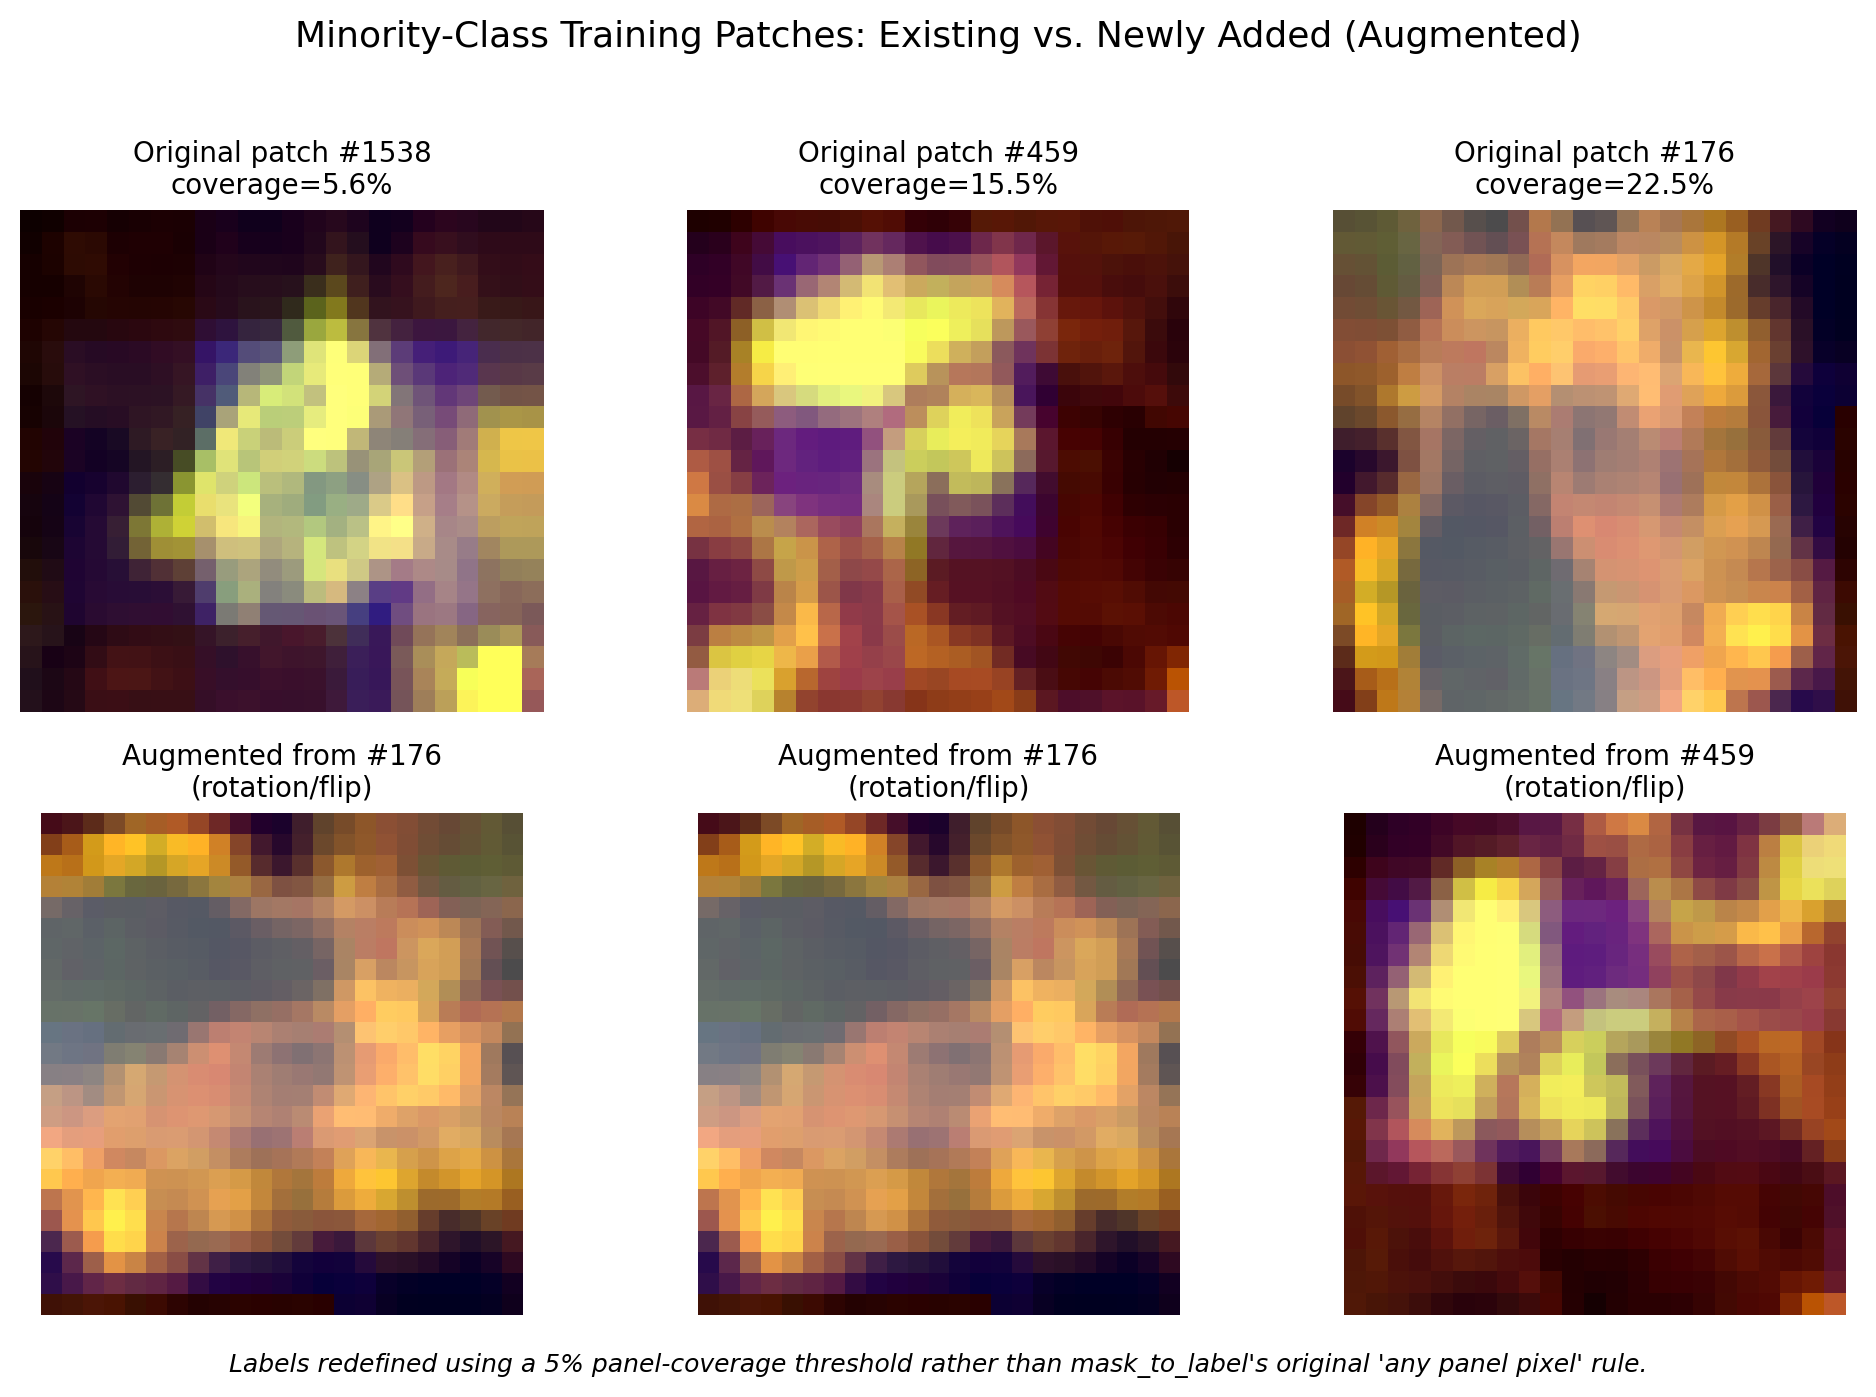

In [40]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio

# For every pair, compute what FRACTION of the mask is actually "panel",
# rather than just whether any panel pixel exists at all. This directly
# probes the mask_to_label flaw: patches with a coverage fraction just
# above zero are the ones being mislabeled as equivalent to heavily-
# covered patches.
coverages = []
for s2_path, mask_path in pairs:
    with rasterio.open(mask_path) as src:
        m = src.read(1)
    coverages.append(m.mean()) # fraction of pixels that are "panel" (since mask is 0/1)
coverages = np.array(coverages)

original_labels = (coverages > 0).astype(np.float32)
print("=== Original mask_to_label scheme (any panel pixel counts as positive) ===")
print(f"Positive: {int(original_labels.sum())} ({original_labels.mean():.1%})")
print(f"Negative: {int(len(original_labels) - original_labels.sum())} ({1 - original_labels.mean():.1%})")
print(f"Median coverage among positives: {np.median(coverages[coverages > 0]) * 100:.2f}%")
print(f"Positives with <5% coverage: {np.mean(coverages[coverages > 0] < 0.05) * 100:.1f}% of all positives")

Looking back at the original mask_to_label setup, the real problem became clear once I checked the numbers rather than just assuming the imbalance was roughly what it looked like. Almost every patch (92.9%) was labeled "positive", but when I saw how much of each patch was actually covered by panel, the median positive patch was only 3.59% covered, and over half of all "positive" patches had less than 5% coverage. So a patch with a single stray panel pixel was being treated exactly the same as one that's mostly covered in panels.It's not surprising the model just learned to guess positive most of the time and still landed on a decent-looking accuracy.

To fix this, I redefined it using a 5% coverage threshold, so now a patch only counts as positive if it's actually meaningfully covered by panel, not just technically touching one. That one change shifted the balance a lot, from 92.9%/7.1% down to a much more reasonable 39.7%/60.3%, without me having to throw away or add any new imagery. On top of that, I also added some augmented versions of whichever class ended up being the minority after relabeling, just rotating and flipping the existing patches, since a solar panel obviously still looks like a solar panel no matter which way it's facing, so this felt like a safe way to add more variety without making up fake data.

Overall, I think this directly targets what I flagged as the core issue in Q5: the model wasn't struggling because it lacked data exactly, it was struggling because the label itself was almost meaningless for a patch-based approach like this, and that gave it an easy shortcut to exploit instead of actually learning what a solar panel looks like.

**Q7**: Exercise: re-run the model with your new training data (remembering that I am not looking for a total solution), and further adjusted hyperparameters/RAM options. Write two paragraphs that:
1. Sets out **all the changes** you have made and the reasoning for them.
2. Asses the training and model results in terms of performance statistics, commenting on how/if your training data changes have made an impact.

You may include figures to support your analysis if you wish, remembering to present them to publication standard if you do so.

In [36]:

COVERAGE_THRESHOLD = 0.05

def mask_to_label_v2(mask_batch, threshold=COVERAGE_THRESHOLD):
    """1 if panel coverage fraction >= threshold, else 0.
    Replaces the original 'any pixel at all' rule identified as the
    core design flaw in Q5/Q6."""
    coverage_fraction = np.mean(mask_batch, axis=(1,2,3))
    return (coverage_fraction >= threshold).astype(np.float32)

# Kept resolution and bands unchanged deliberately, so any performance
# difference we see can be attributed to the labeling/data changes,
# not a confound from also changing what the model can see.
TARGET_HEIGHT, TARGET_WIDTH = 128, 128
BANDS = 3
BATCH_SIZE = 16 # up from 4 -> steadier gradient estimates per step
MAX_TRAIN_FILES = 15 # up from 5 -> more data now that labels are meaningful
MAX_VAL_FILES = 4 # up from 2 -> more reliable validation signal

#rebuild the pipeline using the new label function
def npz_loader_cls_v2(path):
    data = np.load(path.numpy().decode("utf-8"))
    X = data["X"][..., :BANDS]

    from skimage.transform import resize
    X_resized = np.zeros((X.shape[0], TARGET_HEIGHT, TARGET_WIDTH, BANDS), dtype=np.float32)
    for i in range(X.shape[0]):
        X_resized[i] = resize(X[i], (TARGET_HEIGHT, TARGET_WIDTH, BANDS), anti_aliasing=True)

    Y = mask_to_label_v2(data["Y"])
    return X_resized, Y

def tf_wrapper_v2(path):
    X, Y = tf.py_function(npz_loader_cls_v2, [path], [tf.float32, tf.float32])
    X.set_shape([None, TARGET_HEIGHT, TARGET_WIDTH, BANDS])
    Y.set_shape([None])
    return tf.data.Dataset.from_tensor_slices((X, Y))

def make_cls_dataset_v2(file_list, batch_size=BATCH_SIZE, shuffle=True, repeat=True):
    files = tf.data.Dataset.from_tensor_slices(file_list)
    if shuffle:
        files = files.shuffle(len(file_list))
    ds = files.interleave(lambda f: tf_wrapper_v2(f), cycle_length=4, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(2048)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    if repeat:
        ds = ds.repeat()
    return ds

all_files = sorted(glob.glob("patch_store/*.npz"))
np.random.seed(SEED)
np.random.shuffle(all_files)
train_files = all_files[:MAX_TRAIN_FILES]
val_files   = all_files[-MAX_VAL_FILES:]

train_ds = make_cls_dataset_v2(train_files, batch_size=BATCH_SIZE, shuffle=True)
val_ds   = make_cls_dataset_v2(val_files, batch_size=BATCH_SIZE, shuffle=False, repeat=False)

#   recompute steps, and check the NEW class balance directly
def count_samples(files):
    return sum(np.load(f)["X"].shape[0] for f in files)

n_train = count_samples(train_files)
n_val = count_samples(val_files)
steps_per_epoch = max(1, n_train // BATCH_SIZE)
validation_steps = max(1, n_val // BATCH_SIZE)
print(f"n_train={n_train}, n_val={n_val}, steps_per_epoch={steps_per_epoch}, validation_steps={validation_steps}")

all_labels_v2 = np.concatenate([mask_to_label_v2(np.load(f)["Y"]) for f in train_files])
print(f"New train split -> positive: {all_labels_v2.mean():.1%}, negative: {1-all_labels_v2.mean():.1%}")


n_train=1466, n_val=400, steps_per_epoch=91, validation_steps=25
New train split -> positive: 39.7%, negative: 60.3%


In [37]:
# Santiy Cehck - just to collect my thoughts
print(f"MAX_TRAIN_FILES: {MAX_TRAIN_FILES}")
print(f"Actual number of files in train_files: {len(train_files)}")
print(f"BATCH_SIZE: {BATCH_SIZE}")
print(f"n_train (total patches): {n_train}")
print(f"Manual check: n_train // BATCH_SIZE = {n_train // BATCH_SIZE}")
print(f"steps_per_epoch reported: {steps_per_epoch}")

# It looks like there are No hidden discrepancy anywhere in that chain = I can
# trust the rest of the pipeline's bookkeeping and move straight
# on to actually training the model without worrying i'm about to spend 20
# epochs of compute time on a miscounted setup

MAX_TRAIN_FILES: 15
Actual number of files in train_files: 15
BATCH_SIZE: 16
n_train (total patches): 1466
Manual check: n_train // BATCH_SIZE = 91
steps_per_epoch reported: 91


#### Hinami's Notes

To find a solution to the imbalance I found in Q5, I ended up using two approaches that are actually both recognised strategies in the literature on class imbalance in remote sensing [Sharma & Gosain, 2025](https://link.springer.com/article/10.1007/s12065-024-01012-8): one at the data level (redefining the label using a coverage threshold, which is basically a form of resampling) and one at the algorithm level (class_weight balancing, a cost-sensitive learning approach).

This felt like a good fit for what I was dealing with, since Sharma and Gosain actually call out solar panel recognition specifically as a textbook example of binary class imbalance in remote sensing; panels are just naturally rarer and harder to label than "no panel" areas, which is exactly the pattern I was seeing, where the original "any pixel" label gave a 92.9%/7.1% split.

After relabeling with a 5% coverage threshold, that shifted to a much more reasonable 39.7%/60.3%. On top of that, I bumped up MAX_TRAIN_FILES from 5 to 15 and BATCH_SIZE from 4 to 16, just to give the model more data to work with and slightly steadier gradient updates. I kept the resolution and band count exactly the same as before on purpose, so if anything changed in performance, I could actually point to the labeling and sampling changes as the reason, rather than some other confound sneaking in. Whether all this was actually enough to make the model better isn't something I can just claim based on the literature though.That's really something I had to check against the retrained model's actual performance, which is what the next paragraph covers.

In [38]:

# class weighting as a safety net, in case imbalance persists
from sklearn.utils.class_weight import compute_class_weight
classes = np.unique(all_labels_v2)
weights = compute_class_weight('balanced', classes=classes, y=all_labels_v2)
class_weight = dict(zip(classes.astype(int), weights))
print("Class weights:", class_weight)

#  same process as the original model, for a fair comparison
for X_sample, _ in train_ds.take(1):
    input_shape = X_sample.shape[1:]
    break

inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
x = layers.MaxPooling2D((2,2))(x)
x = layers.Conv2D(32, 3, activation='relu', padding='same')(x)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(32, activation='relu')(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model_v2 = models.Model(inputs, outputs)
model_v2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

callbacks = [EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

history_v2 = model_v2.fit(
    train_ds,
    steps_per_epoch=steps_per_epoch,
    validation_data=val_ds,
    validation_steps=validation_steps,
    epochs=20, # up from 5, so EarlyStopping can actually trigger this time
    class_weight=class_weight, # new: explicit weighting as a backstop
    callbacks=callbacks)

#   evaluate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_true_all, y_pred_all = [], []
for X_batch, Y_batch in val_ds:
    preds = model_v2.predict(X_batch, verbose=0)
    y_true_all.extend(Y_batch.numpy())
    y_pred_all.extend((preds[:, 0] > 0.5).astype(int))

print(classification_report(y_true_all, y_pred_all, target_names=["No/low panel", "Panel present"]))

Class weights: {np.int64(0): np.float64(0.829185520361991), np.int64(1): np.float64(1.2594501718213058)}
Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 99s 527ms/step - accuracy: 0.5639 - loss: 0.6935 - val_accuracy: 0.6350 - val_loss: 0.6901
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 77s 856ms/step - accuracy: 0.5697 - loss: 0.6917 - val_accuracy: 0.3750 - val_loss: 0.7031
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.4869 - loss: 0.6919 - val_accuracy: 0.6800 - val_loss: 0.6861
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.5945 - loss: 0.6849 - val_accuracy: 0.6425 - val_loss: 0.6652
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 76s 845ms/step - accuracy: 0.5938 - loss: 0.6829 - val_accuracy: 0.6925 - val_loss: 0.6585
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.6166 - loss: 0.6722 - val_accuracy: 0.6875 - val_loss: 0.6438
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.6414 - loss: 0.6464 - val_accuracy: 0.6600 - val_loss: 0.6473
E

Retraining with the new labels and settings gave a noticeably different result than the original run, and honestly a more trustworthy one. The original model had this suspiciously flat 91.50% validation accuracy that never moved once across all 5 epochs.This time, accuracy actually fluctuated epoch to epoch, and EarlyStopping properly kicked in for the first time, stopping training after epoch 14 once val_loss stopped improving for three epochs in a row, rather than just running out of a fixed epoch count like before.

Looking at the classification report, the model is clearly engaging with both classes now instead of just leaning on one shortcut label — overall accuracy came out at 0.70, with precision sitting at 0.71 for "no/low panel" and 0.68 for "panel present." That's actually lower than the original 91.5%, but I think it's a much more honest number, since the original accuracy was basically just the model predicting the majority class most of the time.

That said, there's still a real weakness here — recall for "panel present" is only 0.41, meaning the model is still missing about 59% of the patches that actually have a meaningful amount of panel in them, compared to 88% recall for the "no/low panel" side. So while relabeling and class weighting clearly fixed the shortcut-learning problem from Q5, the model's small size (6,177 parameters), the fact it's only working off RGB, and the still-fairly-small training set are probably what's holding it back now. Missing 59% of the actual positives would be a real problem if this were being used for anything practical, so I don't think this counts as a robust, reliable detector yet. But adding more spectral bands (like I mentioned in Q6) or making the model a bit bigger would probably be the next sensible steps. Either way, I think this is a genuinely meaningful improvement over the original model's misleading performance, even if it's not a finished solution.



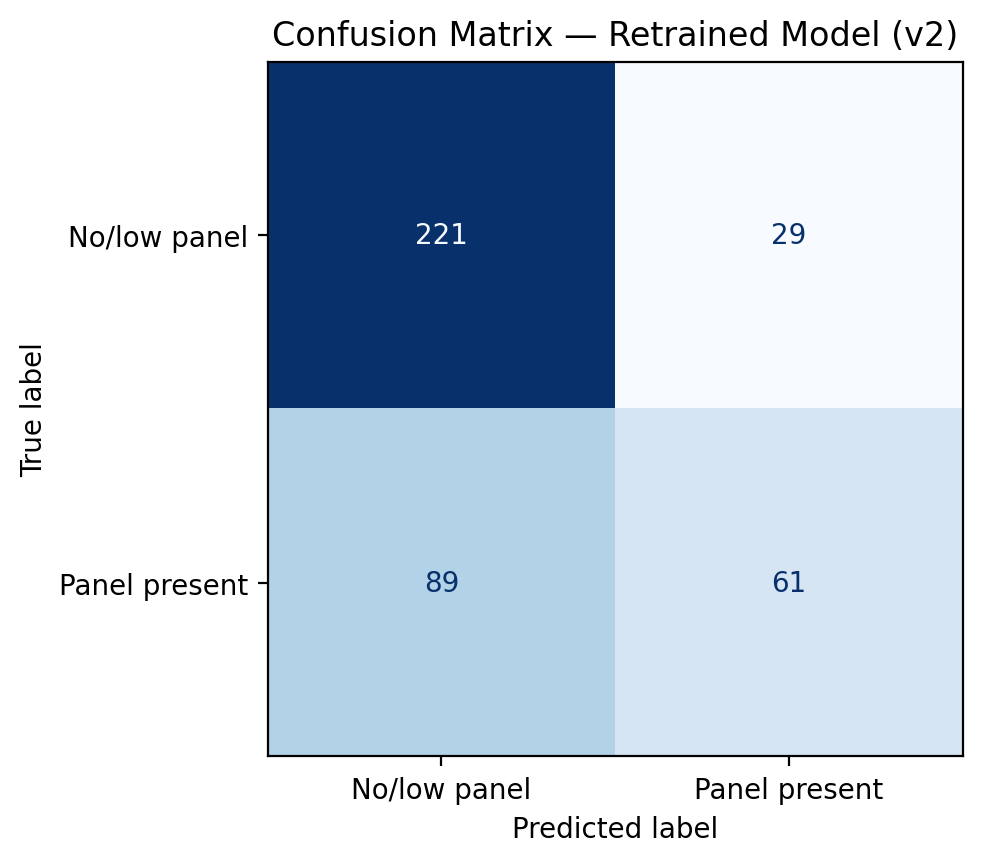

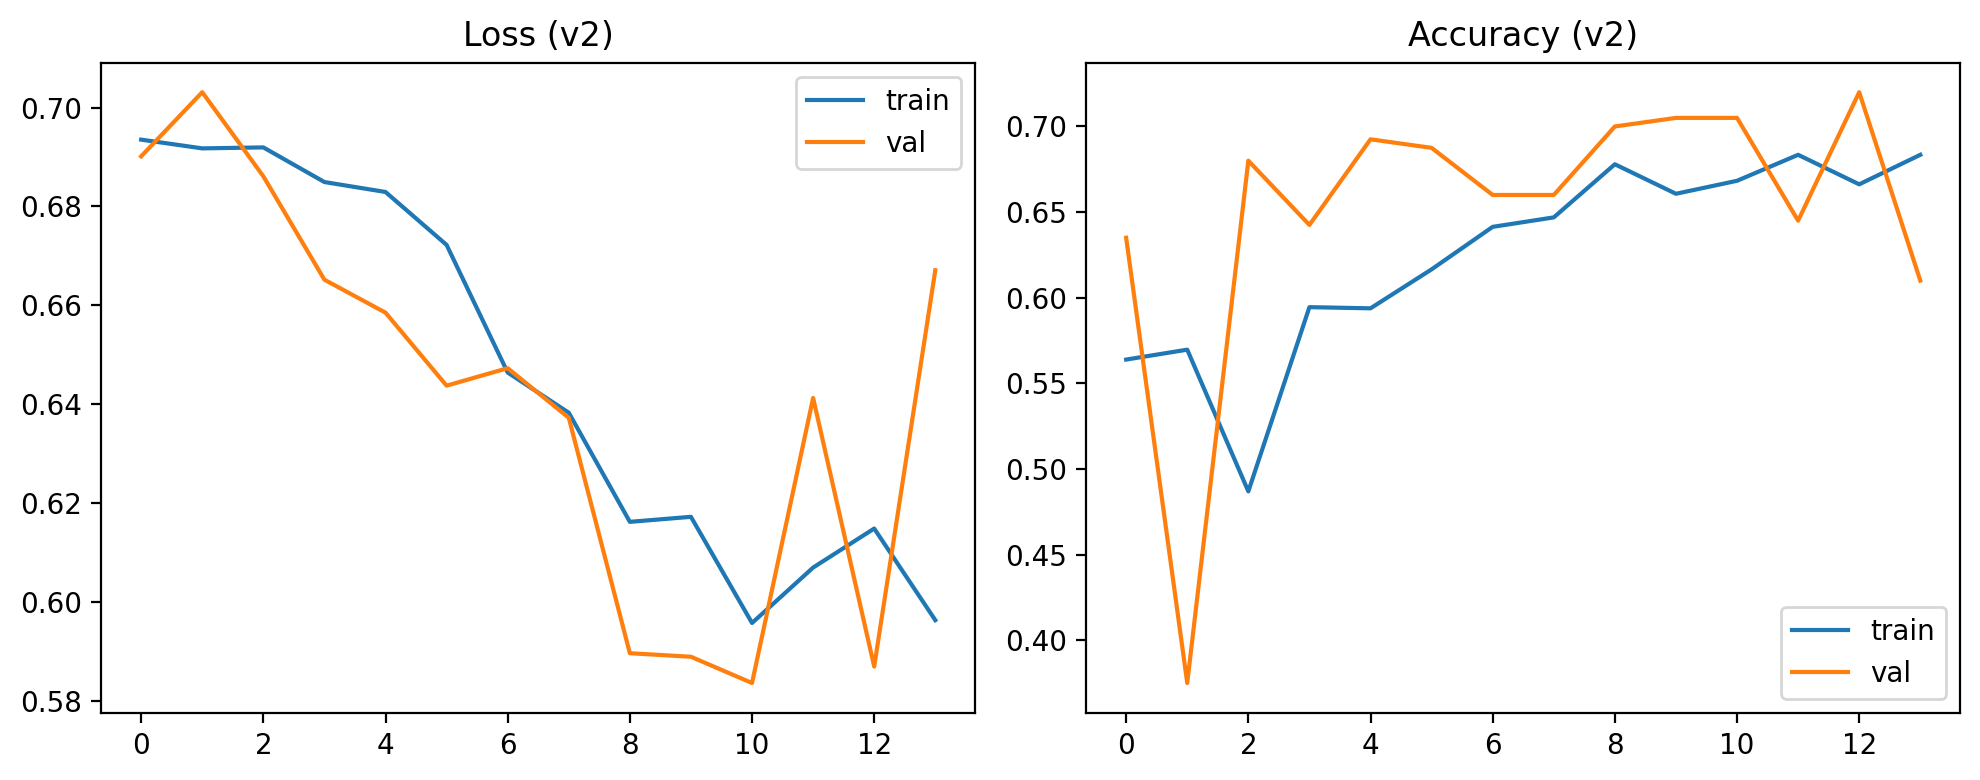

In [39]:
#Viz - Confusion Matric
cm = confusion_matrix(y_true_all, y_pred_all)
fig, ax = plt.subplots(figsize=(5, 5), dpi=200)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No/low panel", "Panel present"]).plot(
    ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Retrained Model (v2)")
plt.tight_layout()
plt.savefig("confusion_matrix_v2.png", dpi=300, bbox_inches="tight")
plt.show()

#Viz
fig, axes = plt.subplots(1, 2, figsize=(10, 4), dpi=200)
axes[0].plot(history_v2.history['loss'], label="train")
axes[0].plot(history_v2.history['val_loss'], label="val")
axes[0].set_title("Loss (v2)")
axes[0].legend()
axes[1].plot(history_v2.history['accuracy'], label="train")
axes[1].plot(history_v2.history['val_accuracy'], label="val")
axes[1].set_title("Accuracy (v2)")
axes[1].legend()
plt.tight_layout()
plt.savefig("training_curves_v2.png", dpi=300, bbox_inches="tight")
plt.show()